In [1]:
import os
import sys
magePath = '/home/benjamin/Documents/analogs/'
os.sys.path.append(magePath)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.io import fits
from astropy import units as u
from scipy.interpolate import interp1d

from magE.functions import air
from magE.spec.natural_spline import *
from magE.spec.spec_classes import *

In [2]:
# Reduced by BN
# _multispec -> with the -2D flag
# _multi -> without the -2D flag

dataPath = '/home/benjamin/Documents/analogs/calib/mage19a/mage19a/'

J0950 = MageMultispec.from_fname(dataPath + 'j0950+0042_multi.fits')
J1146 = MageMultispec.from_fname(dataPath + 'j1146+0053_multi.fits')
J1226 = MageMultispec.from_fname(dataPath + 'j1226+0415_multi.fits')
J1444 = MageMultispec.from_fname(dataPath + 'j1444+0409_multi.fits')
J1448 = MageMultispec.from_fname(dataPath + 'j1448-0110_multi.fits')
J2101 = MageMultispec.from_fname(dataPath + 'j2101-0555_multi.fits')
J2119 = MageMultispec.from_fname(dataPath + 'j2119+0052_multi.fits')

# Read GD108 and LTT7379 1D spectral data
# GD108 and LTT7379 multispec from CarPy

gd108 = MageMultispec.from_fname(dataPath + 'gd108_multi.fits')
ltt7379 = MageMultispec.from_fname(dataPath + 'ltt7379_multi.fits')
hr4963 = MageMultispec.from_fname(dataPath + 'hr4963_multi.fits')

In [3]:
refPath = '/home/benjamin/Documents/analogs/calib/mage19a/'

# gd108 spectrum from ESO Standard Stars
# keys: 0 -> wavelength (A), 1 -> flux (ergs/cm/cm/s/A * 10**16), 2 -> flux (mJy)

gd108_ref = pd.read_csv(refPath + 'fgd108.dat', header=None, 
                           sep='\s+', engine='python')
simple_gd108 = SimpleSpectrum(lda=gd108_ref[0], 
                                 flux=gd108_ref[1]*1e-16)

# ltt7379 spectrum from ESO Standard Stars
# keys: 0 -> wavelength (A), 1 -> flux (ergs/cm/cm/s/A * 10**16)

ltt7379_ref = pd.read_csv(refPath +'fltt7379.dat', header=None, sep='\s+', 
                          engine='python')
simple_ltt7379 = SimpleSpectrum(lda=ltt7379_ref[0], flux=ltt7379_ref[1]*1e-16)

# hr4963 spectrum from ESO Standard Stars
# keys: 0 -> wavelength (A), 1 -> flux (ergs/cm/cm/s/A * 10**16)

hr4963_ref = pd.read_csv(refPath +'fhr4963.dat', header=None, sep='\s+', 
                          engine='python')
simple_hr4963 = SimpleSpectrum(lda=hr4963_ref[0], flux=hr4963_ref[1]*1e-16)

# LTT7379 ref

In [4]:
x_ltt = air(simple_ltt7379.lda)
y_ltt = simple_ltt7379.flux

mask_ltt = (x_ltt < 3793) + (x_ltt > 4042) * (x_ltt < 4170) \
         + (x_ltt > 4499) * (x_ltt < 4796) \
         + (x_ltt > 5350) * (x_ltt < 6425) \
         + (x_ltt > 6634) * (x_ltt < 6786) \
         + (x_ltt > 7765) * (x_ltt < 8078) \
         + (x_ltt > 8720) * (x_ltt < 8881) \
         + (x_ltt > 9892)

knots_ltt = np.array([3412, 3651, 4106, 4652, 5799, 6192, 6706,
                     7918, 8793, 9972])

In [5]:
# building spline based model
model_ltt = get_natural_cubic_spline_model(x=simple_ltt7379.lda[mask_ltt],
                                          y=simple_ltt7379.flux[mask_ltt],
                                          minval=np.min(simple_ltt7379.lda[mask_ltt]),
                                          maxval=np.max(simple_ltt7379.lda[mask_ltt]),
                                          knots=knots_ltt)

# getting flux
y_est_custom_model_ltt = model_ltt.predict(simple_ltt7379.lda)

Text(0.5, 0, '$\\lambda$ [$\\AA$]')

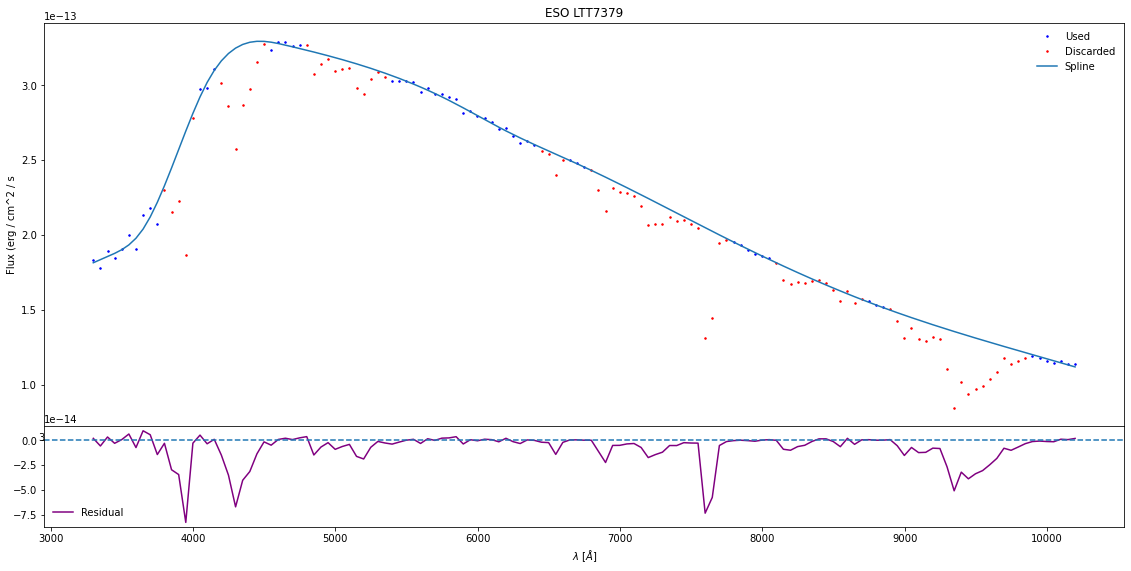

In [6]:
%matplotlib inline

fig = plt.figure(1)
fig.set_size_inches(15, 7)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.plot(simple_ltt7379.lda[mask_ltt], simple_ltt7379.flux[mask_ltt], 
        ls='', marker='.', markersize=3, label='Used', color='blue')
ax.plot(simple_ltt7379.lda[np.logical_not(mask_ltt)], 
        simple_ltt7379.flux[np.logical_not(mask_ltt)], 
        ls='', marker='.', markersize=3, label='Discarded', color='red')
ax.plot(simple_ltt7379.lda, y_est_custom_model_ltt, label='Spline')
ax.legend(frameon=False)
ax.set_ylabel('Flux (erg / cm^2 / s')
ax.set_title('ESO LTT7379')

ax1.plot(x_ltt, y_ltt - y_est_custom_model_ltt, label='Residual', 
         color='purple')
ax1.legend(frameon=False)
ax1.axhline(0, ls='--')
ax1.set_xlabel(r'$\lambda$ [$\AA$]')

In [7]:
reference_lttflux = interp1d(simple_ltt7379.lda,
                              model_ltt.predict(simple_ltt7379.lda),
                              kind='linear', bounds_error=False,
                              fill_value='extrapolate', assume_sorted=True)

# HR4963 ref

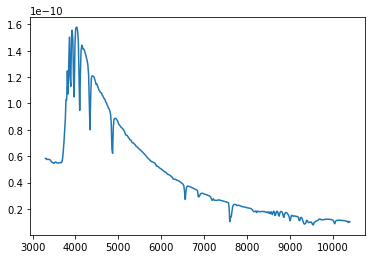

In [8]:
x_hr = air(simple_hr4963.lda)
y_hr = simple_hr4963.flux
plt.plot(x_hr, y_hr)

In [9]:
x_hr = air(simple_hr4963.lda)
y_hr = simple_hr4963.flux

mask_hr = (x_hr < 3760) \
        + (x_hr > 3804) * (x_hr < 3817) \
        + (x_hr > 3848) * (x_hr < 3867) \
        + (x_hr > 3901) * (x_hr < 3944) \
        + (x_hr > 3999) * (x_hr < 4070) \
        + (x_hr > 4160) * (x_hr < 4275) \
        + (x_hr > 4437) * (x_hr < 4778) \
        + (x_hr > 5024) * (x_hr < 6406) \
        + (x_hr > 6646) * (x_hr < 6811) \
        + (x_hr > 6972) * (x_hr < 7114) \
        + (x_hr > 7373) * (x_hr < 7534) \
        + (x_hr > 7819) * (x_hr < 8064) \
        + (x_hr > 8343) * (x_hr < 8402) \
        + (x_hr > 8790) * (x_hr < 8822) \
        + (x_hr > 9100) * (x_hr < 9162) \
        + (x_hr > 9840) * (x_hr < 9975) \
        + (x_hr > 10142) * (x_hr < 10312) \

knots_hr = np.array([3400, 3651, 3730, 3810, 3925, 4010, 4050,
                     4190, 4240, 4490, 4600, 4700, 5200, 5600, 
                    6000, 6200, 6700, 6780, 6990, 7050, 7400,
                    7900, 8370, 8800, 9135, 9900, 10200])

In [10]:
# building spline based model
model_hr = get_natural_cubic_spline_model(x=simple_hr4963.lda[mask_hr],
                                          y=simple_hr4963.flux[mask_hr],
                                          minval=np.min(simple_hr4963.lda[mask_hr]),
                                          maxval=np.max(simple_hr4963.lda[mask_hr]),
                                          knots=knots_hr)

# getting flux
y_est_custom_model_hr = model_hr.predict(simple_hr4963.lda)

Text(0.5, 0, '$\\lambda$ [$\\AA$]')

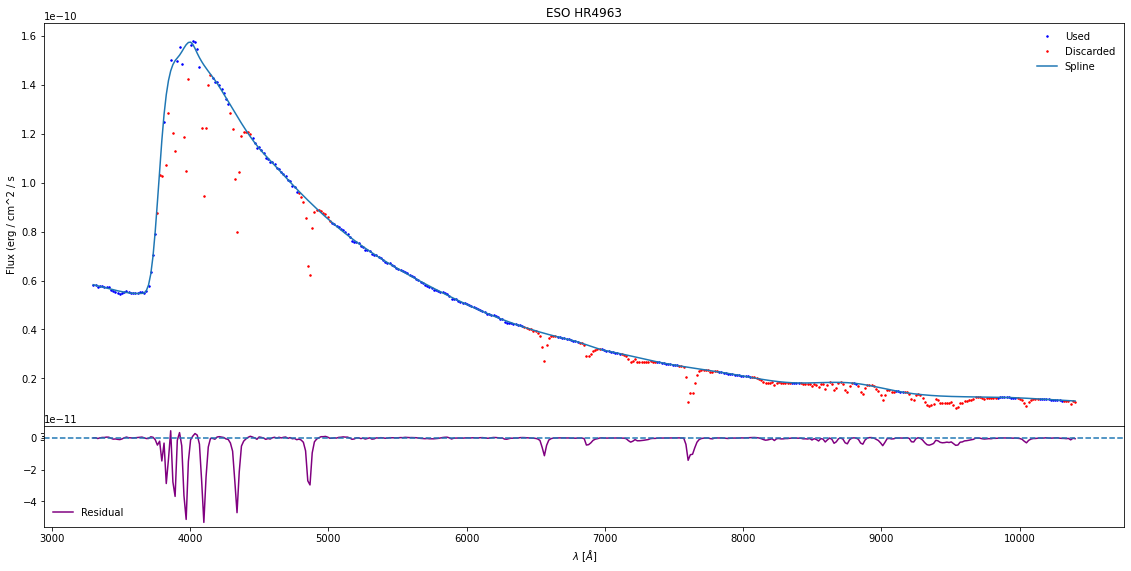

In [11]:
%matplotlib inline

fig = plt.figure(1)
fig.set_size_inches(15, 7)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.plot(simple_hr4963.lda[mask_hr], simple_hr4963.flux[mask_hr], 
        ls='', marker='.', markersize=3, label='Used', color='blue')
ax.plot(simple_hr4963.lda[np.logical_not(mask_hr)], 
        simple_hr4963.flux[np.logical_not(mask_hr)], 
        ls='', marker='.', markersize=3, label='Discarded', color='red')
ax.plot(simple_hr4963.lda, y_est_custom_model_hr, label='Spline')
ax.legend(frameon=False)
ax.set_ylabel('Flux (erg / cm^2 / s')
ax.set_title('ESO HR4963')

ax1.plot(x_hr, y_hr - y_est_custom_model_hr, label='Residual', 
         color='purple')
ax1.legend(frameon=False)
ax1.axhline(0, ls='--')
ax1.set_xlabel(r'$\lambda$ [$\AA$]')

In [12]:
reference_hrflux = interp1d(simple_hr4963.lda,
                              model_hr.predict(simple_hr4963.lda),
                              kind='linear', bounds_error=False,
                              fill_value='extrapolate', assume_sorted=True)

# LTT 7379

## Order 6

In [13]:
xltt6 = ltt7379.wavelength(6)
yltt6 = ltt7379.flux(6)

mask6_ltt = (xltt6 > 9504.07) * (xltt6 < 9515.8) + (xltt6 > 9648.6) * (xltt6 < 9651.8) \
          + (xltt6 > 9893) * (xltt6 < 9897) + (xltt6 > 10105)
knots6_ltt = np.array([9510, 9650, 9895, 10050, 10200, 10400, 11000])

In [14]:
model_custom6_ltt = get_natural_cubic_spline_model(x=xltt6[mask6_ltt],
                                                  y=yltt6[mask6_ltt],
                                                  minval=np.min(xltt6),
                                                  maxval=np.max(xltt6),
                                                  knots=knots6_ltt)

y_est_custom6_ltt = model_custom6_ltt.predict(ltt7379.wavelength(6))

In [15]:
obs_flux6_ltt = spectres(simple_ltt7379.lda, ltt7379.wavelength(6), 
                     y_est_custom6_ltt, verbose=False)

factor6_ltt = reference_lttflux(simple_ltt7379.lda)/obs_flux6_ltt

Text(0.5, 0, '$\\lambda$ [$\\AA$]')

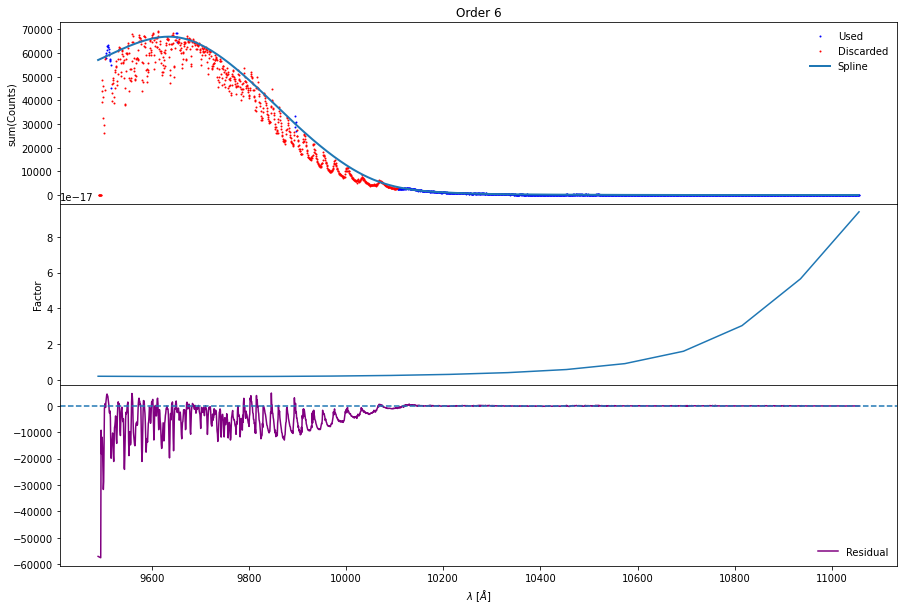

In [16]:
%matplotlib inline
fig, axs = plt.subplots(3, 1, figsize=(15, 10))
fig.subplots_adjust(hspace=0)

axs[0].plot(xltt6[mask6_ltt], yltt6[mask6_ltt], ls='', marker='.', markersize=2,
            label='Used', color='blue')
axs[0].plot(xltt6[np.logical_not(mask6_ltt)], yltt6[np.logical_not(mask6_ltt)],
            ls='', marker='.', markersize=2, label='Discarded', color='red')
axs[0].plot(gd108.wavelength(6), y_est_custom6_ltt, lw=2, label='Spline')
axs[0].legend(frameon=False)
axs[0].set_ylabel('sum(Counts)')
axs[0].set_title('Order 6')

axs[1].plot(simple_ltt7379.lda, factor6_ltt)
axs[1].set_ylabel('Factor')

axs[2].plot(ltt7379.wavelength(6), ltt7379.flux(6) - y_est_custom6_ltt,
            label='Residual', color='purple')
axs[2].legend(frameon=False)
axs[2].axhline(0, ls='--')
axs[2].set_xlabel(r'$\lambda$ [$\AA$]')

## Order 7

In [17]:
xltt7 = ltt7379.wavelength(7)
yltt7 = ltt7379.flux(7)

mask7_ltt = (xltt7 > 8170) * (xltt7 < 8174) + (xltt7 > 8409) * (xltt7 < 8412) \
        + (xltt7 > 8561) * (xltt7 < 8567) \
        + (xltt7 > 8622) * (xltt7 < 8643) + (xltt7 > 8782) * (xltt7 < 8800) \
        + (xltt7 > 8809) * (xltt7 < 8817) + (xltt7 > 8919) * (xltt7 < 8926) \
        + (xltt7 > 9049) * (xltt7 < 9057) + (xltt7 > 9193) * (xltt7 < 9208) \
        + (xltt7 > 9462) * (xltt7 < 9466)

knots7_ltt = np.array([8172, 8411, 8630, 8630, 8790, 8813, 8923, 9053, 
                      9200, 9464])

In [18]:
model_custom7_ltt = get_natural_cubic_spline_model(x=xltt7[mask7_ltt], y=yltt7[mask7_ltt], 
                                               minval=np.min(xltt7), maxval=np.max(xltt7), 
                                               knots=knots7_ltt)

y_est_custom7_ltt = model_custom7_ltt.predict(ltt7379.wavelength(7))

In [19]:
obs_flux7_ltt = spectres(simple_ltt7379.lda, ltt7379.wavelength(7), 
                     y_est_custom7_ltt, verbose=False)

factor7_ltt = reference_lttflux(simple_ltt7379.lda)/obs_flux7_ltt

Text(0.5, 0, '$\\lambda$ [$\\AA$]')

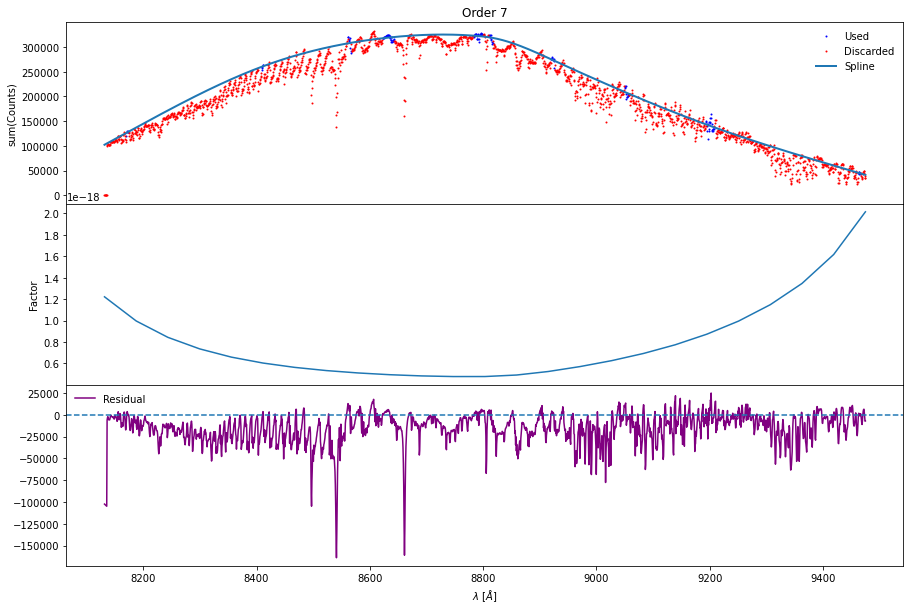

In [20]:
%matplotlib inline

fig, axs = plt.subplots(3, 1, figsize=(15, 10))
fig.subplots_adjust(hspace=0)

axs[0].plot(xltt7[mask7_ltt], yltt7[mask7_ltt], ls='', marker='.', markersize=2,
            label='Used', color='blue')
axs[0].plot(xltt7[np.logical_not(mask7_ltt)], yltt7[np.logical_not(mask7_ltt)],
            ls='', marker='.', markersize=2, label='Discarded', color='red')
#ax[0].errorbar(feige110.wavelength(6), feige110.flux(6), feige110.noise(6), ls='', marker='.', markersize=2, label='Observed')
axs[0].plot(ltt7379.wavelength(7), y_est_custom7_ltt, lw=2, label='Spline')
axs[0].legend(frameon=False)
axs[0].set_ylabel('sum(Counts)')
axs[0].set_title('Order 7')

axs[1].plot(simple_ltt7379.lda, factor7_ltt)
axs[1].set_ylabel('Factor')

axs[2].plot(ltt7379.wavelength(7), ltt7379.flux(7) - y_est_custom7_ltt,
            label='Residual', color='purple')
axs[2].legend(frameon=False)
axs[2].axhline(0, ls='--')
axs[2].set_xlabel(r'$\lambda$ [$\AA$]')

## Order 8

In [21]:
yltt8_1 = ltt7379.flux(8)[5:833]
xltt8_1 = ltt7379.wavelength(8)[5:833]

yltt8_int = ltt7379.flux(8)[833:1032]
xltt8_int = ltt7379.wavelength(8)[833:1032]

yltt8_2 = ltt7379.flux(8)[1032:]
xltt8_2 = ltt7379.wavelength(8)[1032:]

mask8_1_ltt = (xltt8_1 > 7123) * (xltt8_1 < 7144) \
           + (xltt8_1 > 7219) * (xltt8_1 < 7221) \
           + (xltt8_1 > 7378) * (xltt8_1 < 7380) \
           + (xltt8_1 > 7450) * (xltt8_1 < 7457) \
           + (xltt8_1 > 7499) * (xltt8_1 < 7504) \
           + (xltt8_1 > 7559) * (xltt8_1 < 7562)

mask8_2_ltt = (xltt8_2 > 7751) * (xltt8_2 < 7756) + (xltt8_2 > 7835) * (xltt8_2 < 7839) \
           + (xltt8_2 > 7912) * (xltt8_2 < 7914) \
           + (xltt8_2 > 8079) * (xltt8_2 < 8080) \
           + (xltt8_2 > 8245)

#x8 = feige110.flux(8)
#mask8 = (x8 > 7130) * (x8 < 7162) + (x8 > 7209) * (x8 < 7224) + (x8 > 7356) * (x8 < 7537) + (x8 > 7573) * (x8 < 7583) \
#      + (x8 > 7733) * (x8 < 7740) + (x8 > 7794) * (x8 < 8125) + (x8 > 8204) * (x8 < 8219) + (x8 > 8245) * (x8 < 8275)

knots8_1_ltt = np.array([7130, 7220, 7379, 7454, 7502, 7560])
knots8_2_ltt = np.array([7753, 7837, 7913, 8079.5, 8260, 8284])

In [22]:
model_custom8_1_ltt = get_natural_cubic_spline_model(x=xltt8_1[mask8_1_ltt],
                                                 y=yltt8_1[mask8_1_ltt],
                                                 minval=np.min(xltt8_1),
                                                 maxval=np.max(xltt8_1),
                                                 knots=knots8_1_ltt)
y_est_custom8_1_ltt = model_custom8_1_ltt.predict(ltt7379.wavelength(8)[:833])

interp_y8_ltt = interp1d(xltt8_int, yltt8_int, kind='linear', bounds_error=False, 
                     fill_value=np.nan, assume_sorted=True)
y_est_custom8_int_ltt = interp_y8_ltt(xltt8_int)

model_custom8_2_ltt = get_natural_cubic_spline_model(x=xltt8_2[mask8_2_ltt],
                                                 y=yltt8_2[mask8_2_ltt],
                                                 minval=np.min(xltt8_2),
                                                 maxval=np.max(xltt8_2),
                                                 knots=knots8_2_ltt)
y_est_custom8_2_ltt = model_custom8_2_ltt.predict(xltt8_2)

y_est_custom8_ltt = np.concatenate((y_est_custom8_1_ltt, y_est_custom8_int_ltt, 
                                y_est_custom8_2_ltt))

In [23]:
obs_flux8_ltt = spectres(simple_ltt7379.lda, ltt7379.wavelength(8), 
                     y_est_custom8_ltt, verbose=False)
factor8_ltt = reference_lttflux(simple_ltt7379.lda)/obs_flux8_ltt

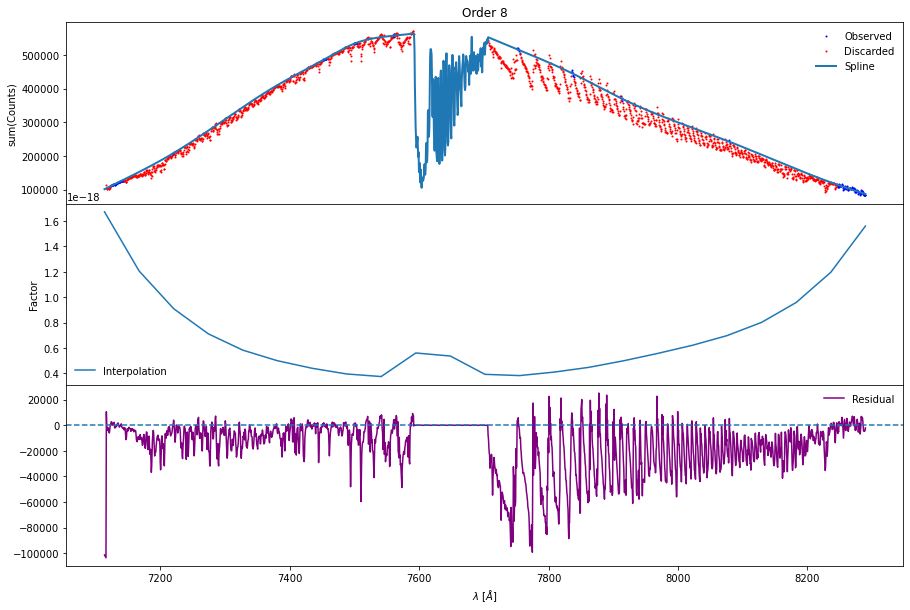

In [24]:
%matplotlib inline
fig, axs = plt.subplots(3, 1, figsize=(15, 10))
fig.subplots_adjust(hspace=0)

axs[0].plot(xltt8_1[mask8_1_ltt], yltt8_1[mask8_1_ltt],
            ls='', marker='.', markersize=2, label='Observed', color='blue')
axs[0].plot(xltt8_2[mask8_2_ltt], yltt8_2[mask8_2_ltt],
            ls='', marker='.', markersize=2, color='blue')
axs[0].plot(xltt8_1[np.logical_not(mask8_1_ltt)], yltt8_1[np.logical_not(mask8_1_ltt)],
            ls='', marker='.', markersize=2, label='Discarded', color='red')
axs[0].plot(xltt8_2[np.logical_not(mask8_2_ltt)], yltt8_2[np.logical_not(mask8_2_ltt)],
            ls='', marker='.', markersize=2, color='red')
axs[0].plot(ltt7379.wavelength(8), y_est_custom8_ltt, lw=2, label='Spline')
axs[0].legend(frameon=False)
axs[0].set_ylabel('sum(Counts)')
axs[0].set_title('Order 8')

axs[1].plot(simple_ltt7379.lda, factor8_ltt, label='Interpolation')
axs[1].set_ylabel('Factor')
axs[1].legend(frameon=False)

axs[2].plot(ltt7379.wavelength(8), ltt7379.flux(8) - y_est_custom8_ltt,
            label='Residual', color='purple')
axs[2].legend(frameon=False)
axs[2].axhline(0, ls='--')
axs[2].set_xlabel(r'$\lambda$ [$\AA$]');

## Order 9

In [25]:
yltt9_1 = ltt7379.flux(9)[:1056]
xltt9_1 = ltt7379.wavelength(9)[:1056]

yltt9_int = ltt7379.flux(9)[1056:1218]
xltt9_int = ltt7379.wavelength(9)[1056:1218]

yltt9_2 = ltt7379.flux(9)[1218:]
xltt9_2 = ltt7379.wavelength(9)[1218:]

mask9_1_ltt = (xltt9_1 > 6329) * (xltt9_1 < 6460) + (xltt9_1 > 6578) * (xltt9_1 < 6581) \
           + (xltt9_1 > 6666) * (xltt9_1 < 6669) + (xltt9_1 > 6774) * (xltt9_1 < 6778) \
           + (xltt9_1 > 6844) * (xltt9_1 < 6860)

mask9_2_ltt = (xltt9_2 > 6965) * (xltt9_2 < 6974) + (xltt9_2 > 7041) * (xltt9_2 < 7049) \
           + (xltt9_2 > 7112) * (xltt9_2 < 7119) + (xltt9_2 > 7321) * (xltt9_2 < 7360)

knots9_1_ltt = np.array([6338, 6370, 6390, 6420, 6579, 6667, 6776, 6855])
knots9_2_ltt = np.array([6970, 7045, 7116, 7350, 7359])

In [26]:
model_custom9_1_ltt = get_natural_cubic_spline_model(x=xltt9_1[mask9_1_ltt], 
                                                 y=yltt9_1[mask9_1_ltt], 
                                                 minval=np.min(xltt9_1), 
                                                 maxval=np.max(xltt9_1), 
                                                 knots=knots9_1_ltt)
y_est_custom9_1_ltt = model_custom9_1_ltt.predict(ltt7379.wavelength(9)[:1056])

interp_y9_ltt = interp1d(xltt9_int, yltt9_int, kind='linear', bounds_error=False, 
                     fill_value=np.nan, assume_sorted=True)
y_est_custom9_int_ltt = interp_y9_ltt(xltt9_int)

model_custom9_2_ltt = get_natural_cubic_spline_model(x=xltt9_2[mask9_2_ltt],
                                                 y=yltt9_2[mask9_2_ltt],
                                                 minval=np.min(xltt9_2),
                                                 maxval=np.max(xltt9_2),
                                                 knots=knots9_2_ltt)
y_est_custom9_2_ltt = model_custom9_2_ltt.predict(xltt9_2)

y_est_custom9_ltt = np.concatenate((y_est_custom9_1_ltt, 
                                   y_est_custom9_int_ltt, 
                                   y_est_custom9_2_ltt))

In [27]:
obs_flux9_ltt = spectres(simple_ltt7379.lda, ltt7379.wavelength(9), 
                     y_est_custom9_ltt, verbose=False)
factor9_ltt = reference_lttflux(simple_ltt7379.lda)/obs_flux9_ltt

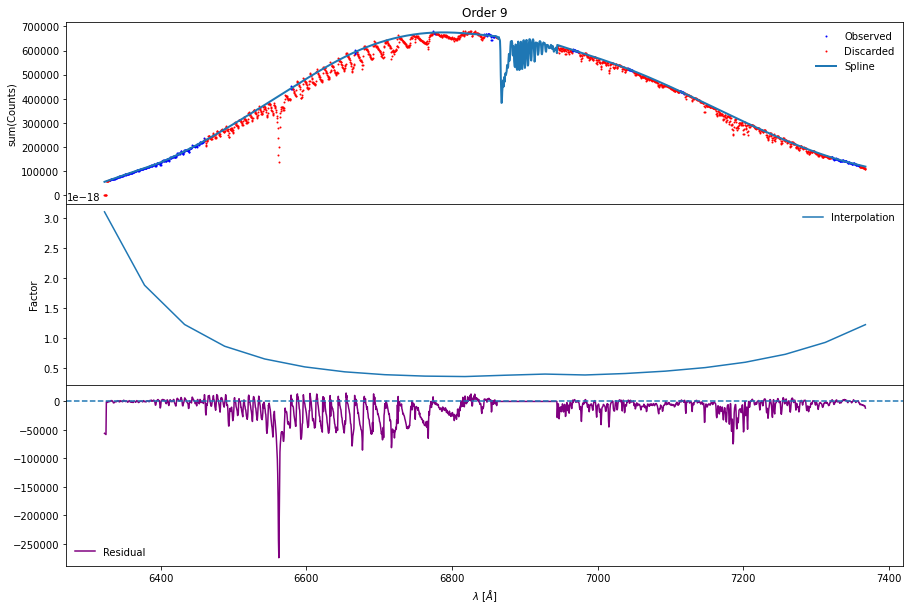

In [28]:
%matplotlib inline
fig, axs = plt.subplots(3, 1, figsize=(15, 10))
fig.subplots_adjust(hspace=0)

axs[0].plot(xltt9_1[mask9_1_ltt], yltt9_1[mask9_1_ltt],
            ls='', marker='.', markersize=2, label='Observed', color='blue')
axs[0].plot(xltt9_2[mask9_2_ltt], yltt9_2[mask9_2_ltt],
            ls='', marker='.', markersize=2, color='blue')
axs[0].plot(xltt9_1[np.logical_not(mask9_1_ltt)], yltt9_1[np.logical_not(mask9_1_ltt)],
            ls='', marker='.', markersize=2, label='Discarded', color='red')
axs[0].plot(xltt9_2[np.logical_not(mask9_2_ltt)], yltt9_2[np.logical_not(mask9_2_ltt)],
            ls='', marker='.', markersize=2, color='red')
axs[0].plot(ltt7379.wavelength(9), y_est_custom9_ltt, lw=2, label='Spline')
axs[0].legend(frameon=False)
axs[0].set_ylabel('sum(Counts)')
axs[0].set_title('Order 9')

axs[1].plot(simple_ltt7379.lda, factor9_ltt, label='Interpolation')
axs[1].set_ylabel('Factor')
axs[1].legend(frameon=False)

axs[2].plot(ltt7379.wavelength(9), ltt7379.flux(9) - y_est_custom9_ltt,
            label='Residual', color='purple')
axs[2].legend(frameon=False)
axs[2].axhline(0, ls='--')
axs[2].set_xlabel(r'$\lambda$ [$\AA$]');

## Order 10

In [29]:
yltt10 = ltt7379.flux(10)
xltt10 = ltt7379.wavelength(10)

mask10_ltt = (xltt10 > 5692) * (xltt10 < 5873) + (xltt10 > 5993) * (xltt10 < 5995) \
           + (xltt10 > 6104) * (xltt10 < 6106) + (xltt10 > 6200) * (xltt10 < 6210) \
           + (xltt10 > 6271) * (xltt10 < 6275) + (xltt10 > 6371) * (xltt10 < 6374.5) \
           + (xltt10 > 6616) * (xltt10 < 6625)

knots10_ltt = np.array([5698, 5710, 5758, 5829, 5994, 6105, 6205, 6273, 6373, 
                        6600, 6620])

In [30]:
model_custom10_ltt = get_natural_cubic_spline_model(x=xltt10[mask10_ltt],
                                                y=yltt10[mask10_ltt],
                                                minval=np.min(xltt10),
                                                maxval=np.max(xltt10),
                                                knots=knots10_ltt)
y_est_custom10_ltt = model_custom10_ltt.predict(ltt7379.wavelength(10))

In [31]:
obs_flux10_ltt = spectres(simple_ltt7379.lda, ltt7379.wavelength(10), 
                      y_est_custom10_ltt, verbose=False)
factor10_ltt = reference_lttflux(simple_ltt7379.lda)/obs_flux10_ltt

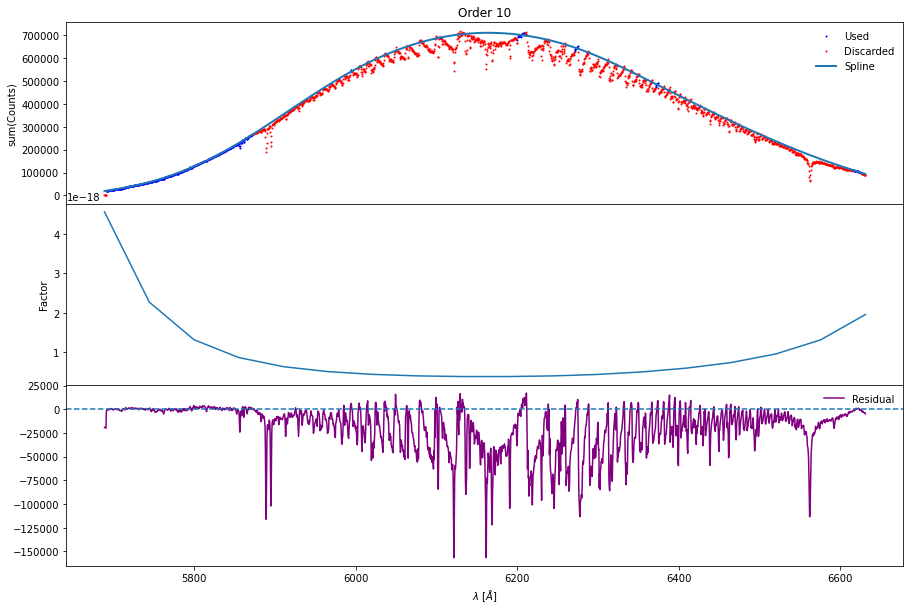

In [32]:
%matplotlib inline
fig, axs = plt.subplots(3, 1, figsize=(15, 10))
fig.subplots_adjust(hspace=0)

axs[0].plot(xltt10[mask10_ltt], yltt10[mask10_ltt], ls='', marker='.',
            markersize=2, label='Used', color='blue')
axs[0].plot(xltt10[np.logical_not(mask10_ltt)], yltt10[np.logical_not(mask10_ltt)],
            ls='', marker='.', markersize=2, label='Discarded', color='red')
axs[0].plot(ltt7379.wavelength(10), y_est_custom10_ltt, lw=2, label='Spline')
axs[0].legend(frameon=False)
axs[0].set_ylabel('sum(Counts)')
axs[0].set_title('Order 10')

axs[1].plot(simple_ltt7379.lda, factor10_ltt)
axs[1].set_ylabel('Factor')

axs[2].plot(ltt7379.wavelength(10), ltt7379.flux(10) - y_est_custom10_ltt,
            label='Residual', color='purple')
axs[2].legend(frameon=False)
axs[2].axhline(0, ls='--')
axs[2].set_xlabel(r'$\lambda$ [$\AA$]');

## Order 11

In [33]:
xltt11 = ltt7379.wavelength(11)
yltt11 = ltt7379.flux(11)

mask11_ltt = (xltt11 > 5174) * (xltt11 < 5280) + (xltt11 > 5351) * (xltt11 < 5361) \
            + (xltt11 > 5457) * (xltt11 < 5461) + (xltt11 > 5536) * (xltt11 < 5541) \
            + (xltt11 > 5644) * (xltt11 < 5648) \
            + (xltt11 > 5742) * (xltt11 < 5745) + (xltt11 > 5819) * (xltt11 < 5871) \
            + (xltt11 > 5904)

knots11_ltt = np.array([5183, 5233, 5356, 5458, 5538, 
                        5646, 5743, 5845, 5908, 5940,
                        5978, 6021])

In [34]:
model_custom11_ltt = get_natural_cubic_spline_model(x=xltt11[mask11_ltt],
                                                   y=yltt11[mask11_ltt],
                                                   minval=np.min(xltt11),
                                                   maxval=np.max(xltt11),
                                                   knots=knots11_ltt)
y_est_custom11_ltt = model_custom11_ltt.predict(ltt7379.wavelength(11))

In [35]:
obs_flux11_ltt = spectres(simple_ltt7379.lda, ltt7379.wavelength(11), 
                      y_est_custom11_ltt, verbose=False)
factor11_ltt = reference_lttflux(simple_ltt7379.lda)/obs_flux11_ltt

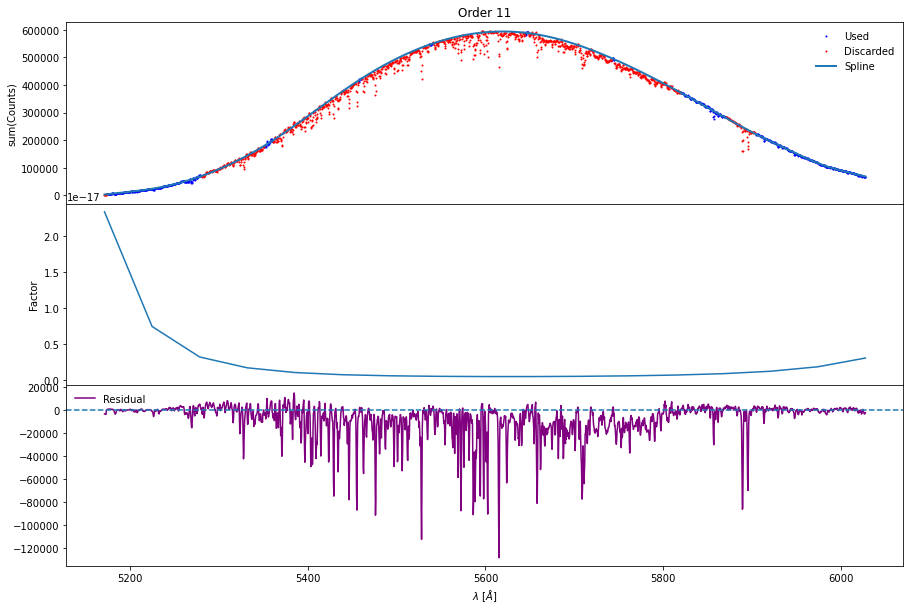

In [36]:
%matplotlib inline
fig, axs = plt.subplots(3, 1, figsize=(15, 10))
fig.subplots_adjust(hspace=0)

axs[0].plot(xltt11[mask11_ltt], yltt11[mask11_ltt],
            ls='', marker='.', markersize=2, label='Used', color='blue')
axs[0].plot(xltt11[np.logical_not(mask11_ltt)], yltt11[np.logical_not(mask11_ltt)],
            ls='', marker='.', markersize=2, label='Discarded', color='red')
axs[0].plot(ltt7379.wavelength(11), y_est_custom11_ltt, lw=2, label='Spline')
axs[0].legend(frameon=False)
axs[0].set_ylabel('sum(Counts)')
axs[0].set_title('Order 11')

axs[1].plot(simple_ltt7379.lda, factor11_ltt)
axs[1].set_ylabel('Factor')

axs[2].plot(ltt7379.wavelength(11), ltt7379.flux(11) - y_est_custom11_ltt,
            label='Residual', color='purple')
axs[2].legend(frameon=False)
axs[2].axhline(0, ls='--')
axs[2].set_xlabel(r'$\lambda$ [$\AA$]');

## Order 12

In [37]:
yltt12 = ltt7379.flux(12)
xltt12 = ltt7379.wavelength(12)

mask12_ltt = (xltt12 > 4740) * (xltt12 < 4850) + (xltt12 > 4913) * (xltt12 < 4916) \
           + (xltt12 > 4986) * (xltt12 < 4988) + (xltt12 > 5031) * (xltt12 < 5034) \
           + (xltt12 > 5085) * (xltt12 < 5087) \
           + (xltt12 > 5156) * (xltt12 < 5160) + (xltt12 > 5255) * (xltt12 < 5258) \
           + (xltt12 > 5354) * (xltt12 < 5360) + (xltt12 > 5420)

knots12_ltt = np.array([4750, 4800, 4840, 4914, 4987, 5033,
                    5086, 5158, 5256, 5357,
                    5440, 5470, 5520])

In [38]:
model_custom12_ltt = get_natural_cubic_spline_model(x=xltt12[mask12_ltt],
                                                y=yltt12[mask12_ltt],
                                                minval=np.min(xltt12),
                                                maxval=np.max(xltt12),
                                                knots=knots12_ltt)
y_est_custom12_ltt = model_custom12_ltt.predict(ltt7379.wavelength(12))

In [39]:
obs_flux12_ltt = spectres(simple_ltt7379.lda, ltt7379.wavelength(12), 
                      y_est_custom12_ltt, verbose=False)
factor12_ltt = reference_lttflux(simple_ltt7379.lda)/obs_flux12_ltt

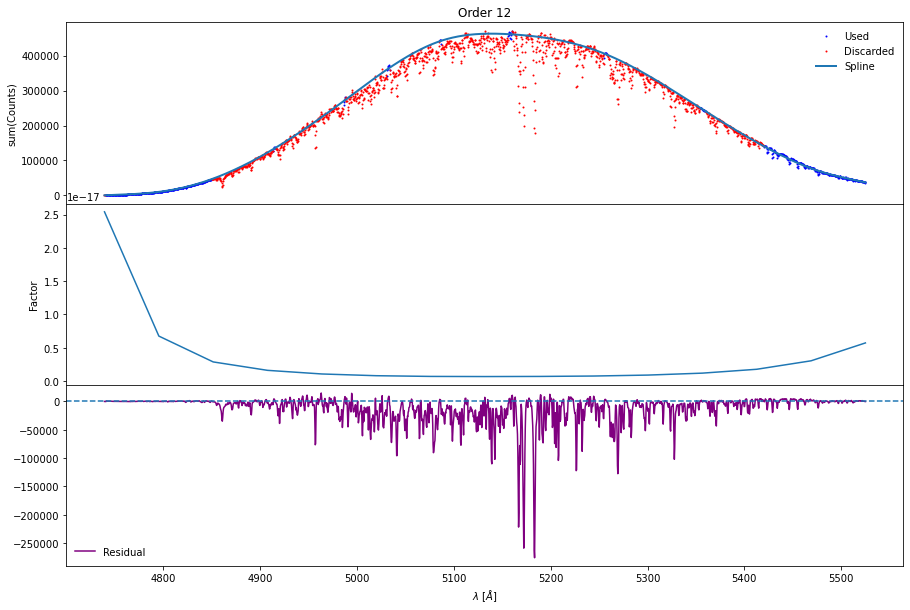

In [40]:
%matplotlib inline
fig, axs = plt.subplots(3, 1, figsize=(15, 10))
fig.subplots_adjust(hspace=0)

axs[0].plot(xltt12[mask12_ltt], yltt12[mask12_ltt], ls='',
            marker='.', markersize=2, label='Used', color='blue')
axs[0].plot(xltt12[np.logical_not(mask12_ltt)], yltt12[np.logical_not(mask12_ltt)],
            ls='', marker='.', markersize=2, label='Discarded', color='red')
axs[0].plot(ltt7379.wavelength(12), y_est_custom12_ltt, lw=2, label='Spline')
axs[0].legend(frameon=False)
axs[0].set_ylabel('sum(Counts)')
axs[0].set_title('Order 12')

axs[1].plot(simple_ltt7379.lda, factor12_ltt)
axs[1].set_ylabel('Factor')

axs[2].plot(ltt7379.wavelength(12), ltt7379.flux(12) - y_est_custom12_ltt,
            label='Residual', color='purple')
axs[2].legend(frameon=False)
axs[2].axhline(0, ls='--')
axs[2].set_xlabel(r'$\lambda$ [$\AA$]');

## Order 13

In [41]:
yltt13 = ltt7379.flux(13)
xltt13 = ltt7379.wavelength(13)

mask13_ltt = (xltt13 > 4376) * (xltt13 < 4468) + (xltt13 > 4475) * (xltt13 < 4524) \
          + (xltt13 > 4572) * (xltt13 < 4573) + (xltt13 > 4657) * (xltt13 < 4661) \
          + (xltt13 > 4723) * (xltt13 < 4726) + (xltt13 > 4773) * (xltt13 < 4777) \
          + (xltt13 > 4816) * (xltt13 < 4819) + (xltt13 > 4961)

knots13_ltt = np.array([4379, 4429, 4486, 4520, 4572.5, 4659, 4725, 4775, 4818,
                        4962, 5016, 5051, 5091])

In [42]:
model_custom13_ltt = get_natural_cubic_spline_model(x=xltt13[mask13_ltt],
                                                y=yltt13[mask13_ltt],
                                                minval=np.min(xltt13),
                                                maxval=np.max(xltt13),
                                                knots=knots13_ltt)
y_est_custom13_ltt = model_custom13_ltt.predict(ltt7379.wavelength(13))

In [43]:
obs_flux13_ltt = spectres(simple_ltt7379.lda, ltt7379.wavelength(13),
                      y_est_custom13_ltt, verbose=False)
factor13_ltt = reference_lttflux(simple_ltt7379.lda)/obs_flux13_ltt

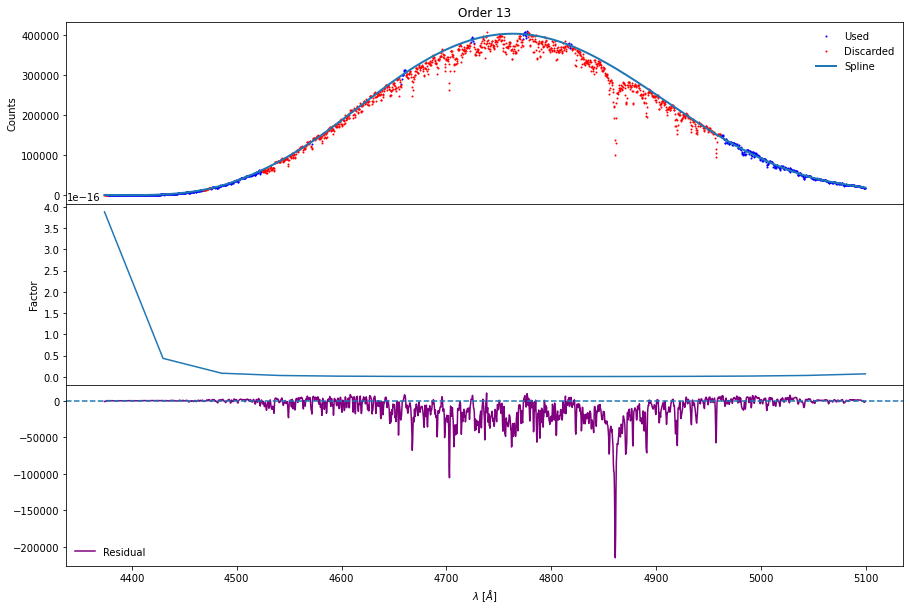

In [44]:
%matplotlib inline
fig, axs = plt.subplots(3, 1, figsize=(15, 10))
fig.subplots_adjust(hspace=0)

axs[0].plot(xltt13[mask13_ltt], yltt13[mask13_ltt], ls='',
            marker='.', markersize=2, label='Used', color='blue')
axs[0].plot(xltt13[np.logical_not(mask13_ltt)], yltt13[np.logical_not(mask13_ltt)],
            ls='', marker='.', markersize=2, label='Discarded', color='red')
#axs[0].errorbar(feige110.wavelength(13), feige110.flux(13), feige110.noise(13), ls='', marker='.', markersize=2, label='Observed')
axs[0].plot(ltt7379.wavelength(13), y_est_custom13_ltt, lw=2, label='Spline')
axs[0].legend(frameon=False)
axs[0].set_ylabel('Counts')
axs[0].set_title('Order 13')

axs[1].plot(simple_ltt7379.lda, factor13_ltt)
axs[1].set_ylabel('Factor')

axs[2].plot(ltt7379.wavelength(13), ltt7379.flux(13) - y_est_custom13_ltt, 
            label='Residual', color='purple')
axs[2].legend(frameon=False)
axs[2].axhline(0, ls='--')
axs[2].set_xlabel(r'$\lambda$ [$\AA$]');

## Order 14

In [45]:
yltt14 = ltt7379.flux(14)
xltt14 = ltt7379.wavelength(14)

mask14_ltt = (xltt14 > 4062) * (xltt14 < 4221) + (xltt14 > 4316) * (xltt14 < 4318) \
          + (xltt14 > 4418) * (xltt14 < 4421) + (xltt14 > 4476) * (xltt14 < 4478) \
          + (xltt14 > 4503) * (xltt14 < 4506) + (xltt14 > 4573) * (xltt14 < 4678) \
          + (xltt14 > 4692)

knots14_ltt = np.array([4068, 4127, 4142, 4317, 4419,
                        4477, 4504, 4614, 4646, 4701, 4729])

In [46]:
model_custom14_ltt = get_natural_cubic_spline_model(x=xltt14[mask14_ltt], 
                                                y=yltt14[mask14_ltt], 
                                                minval=np.min(xltt14), 
                                                maxval=np.max(xltt14), 
                                                knots=knots14_ltt)
y_est_custom14_ltt = model_custom14_ltt.predict(ltt7379.wavelength(14))

In [47]:
obs_flux14_ltt = spectres(simple_ltt7379.lda, ltt7379.wavelength(14),
                         y_est_custom14_ltt, verbose=False)
factor14_ltt = reference_lttflux(simple_ltt7379.lda)/obs_flux14_ltt

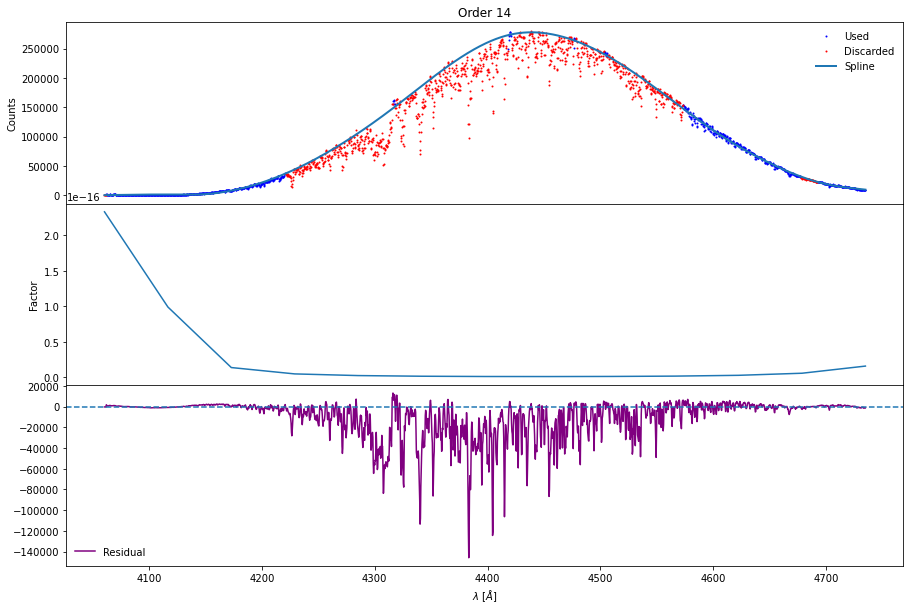

In [48]:
%matplotlib inline
fig, axs = plt.subplots(3, 1, figsize=(15, 10))
fig.subplots_adjust(hspace=0)

axs[0].plot(xltt14[mask14_ltt], yltt14[mask14_ltt], ls='', marker='.',
            markersize=2, label='Used', color='blue')
axs[0].plot(xltt14[np.logical_not(mask14_ltt)], yltt14[np.logical_not(mask14_ltt)], ls='',
            marker='.', markersize=2, label='Discarded', color='red')
axs[0].plot(ltt7379.wavelength(14), y_est_custom14_ltt, lw=2, label='Spline')
axs[0].legend(frameon=False)
axs[0].set_ylabel('Counts')
axs[0].set_title('Order 14')

axs[1].plot(simple_ltt7379.lda, factor14_ltt)
axs[1].set_ylabel('Factor')

axs[2].plot(ltt7379.wavelength(14), ltt7379.flux(14) - y_est_custom14_ltt,
            label='Residual', color='purple')
axs[2].legend(frameon=False)
axs[2].axhline(0, ls='--')
axs[2].set_xlabel(r'$\lambda$ [$\AA$]');

## Order 15

In [49]:
yltt15 = ltt7379.flux(15)
xltt15 = ltt7379.wavelength(15)

mask15_ltt = (xltt15 > 3790) * (xltt15 < 3917) + (xltt15 > 3945) * (xltt15 < 3955) \
          + (xltt15 > 4001) * (xltt15 < 4003) + (xltt15 > 4088) * (xltt15 < 4091) \
          + (xltt15 > 4135) * (xltt15 < 4141) + (xltt15 > 4164) * (xltt15 < 4166) \
          + (xltt15 > 4192) * (xltt15 < 4194) + (xltt15 > 4262) * (xltt15 < 4266) \
          + (xltt15 > 4315) * (xltt15 < 4321) + (xltt15 > 4357)

knots15_ltt = np.array([3797, 3840, 3876, 3891, 3950, 4002, 4090,
                        4138, 4165, 4193, 4264, 4320, 4367, 4402])

In [50]:
model_custom15_ltt = get_natural_cubic_spline_model(x=xltt15[mask15_ltt],
                                                y=yltt15[mask15_ltt],
                                                minval=np.min(xltt15),
                                                maxval=np.max(xltt15),
                                                knots=knots15_ltt)
y_est_custom15_ltt = model_custom15_ltt.predict(ltt7379.wavelength(15))

In [51]:
obs_flux15_ltt = spectres(simple_ltt7379.lda, ltt7379.wavelength(15),
                      y_est_custom15_ltt, verbose=False)
factor15_ltt = reference_lttflux(simple_ltt7379.lda)/obs_flux15_ltt

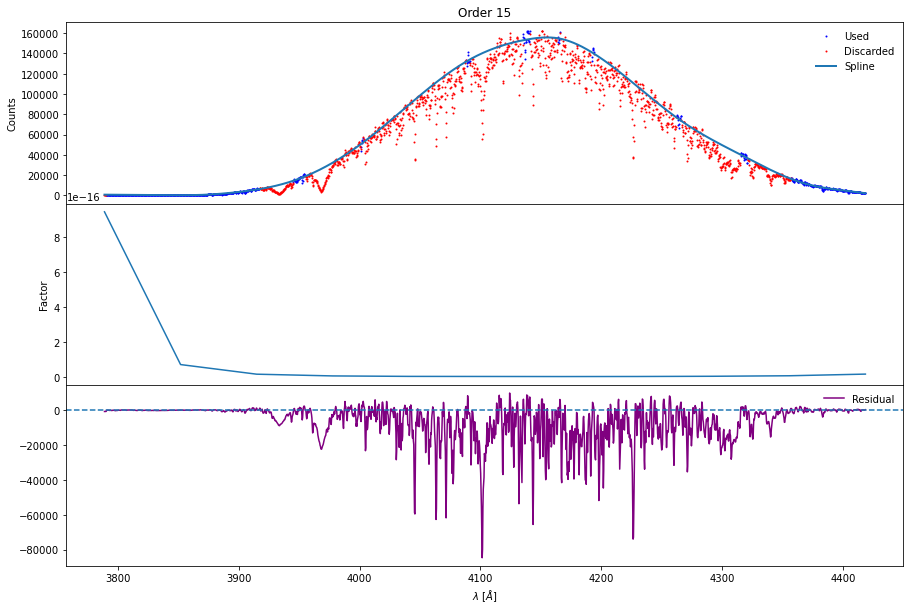

In [52]:
%matplotlib inline
fig, axs = plt.subplots(3, 1, figsize=(15, 10))
fig.subplots_adjust(hspace=0)

axs[0].plot(xltt15[mask15_ltt], yltt15[mask15_ltt], ls='', marker='.',
            markersize=2, label='Used', color='blue')
axs[0].plot(xltt15[np.logical_not(mask15_ltt)], yltt15[np.logical_not(mask15_ltt)],
            ls='', marker='.', markersize=2, label='Discarded', color='red')
axs[0].plot(ltt7379.wavelength(15), y_est_custom15_ltt, lw=2, label='Spline')
axs[0].legend(frameon=False)
axs[0].set_ylabel('Counts')
axs[0].set_title('Order 15')

axs[1].plot(simple_ltt7379.lda, factor15_ltt)
axs[1].set_ylabel('Factor')

axs[2].plot(ltt7379.wavelength(15), ltt7379.flux(15) - y_est_custom15_ltt,
            label='Residual', color='purple')
axs[2].legend(frameon=False)
axs[2].axhline(0, ls='--')
axs[2].set_xlabel(r'$\lambda$ [$\AA$]');

## Order 16

In [53]:
yltt16 = ltt7379.flux(16)
xltt16 = ltt7379.wavelength(16)

mask16_ltt = (xltt16 > 3552) * (xltt16 < 3702)  \
           + (xltt16 > 3783) * (xltt16 < 3785) + (xltt16 > 3808) * (xltt16 < 3812) \
           + (xltt16 > 3862) * (xltt16 < 3865) + (xltt16 > 3914) * (xltt16 < 3915.5) \
           + (xltt16 > 4007) * (xltt16 < 4008.5) \
           + (xltt16 > 4059) * (xltt16 < 4062) + (xltt16 > 4110)

knots16_ltt = np.array([3554, 3561, 3618, 3677, 3784, 3811, 3863, 3914.5,
                        4008, 4060, 4120, 4138])

In [54]:
model_custom16_ltt = get_natural_cubic_spline_model(x=xltt16[mask16_ltt],
                                                y=yltt16[mask16_ltt],
                                                minval=np.min(xltt16),
                                                maxval=np.max(xltt16),
                                                knots=knots16_ltt)
y_est_custom16_ltt = model_custom16_ltt.predict(ltt7379.wavelength(16))

In [55]:
obs_flux16_ltt = spectres(simple_ltt7379.lda, ltt7379.wavelength(16),
                      y_est_custom16_ltt, verbose=False)
factor16_ltt = reference_lttflux(simple_ltt7379.lda)/obs_flux16_ltt

Text(0.5, 0, '$\\lambda$ [$\\AA$]')

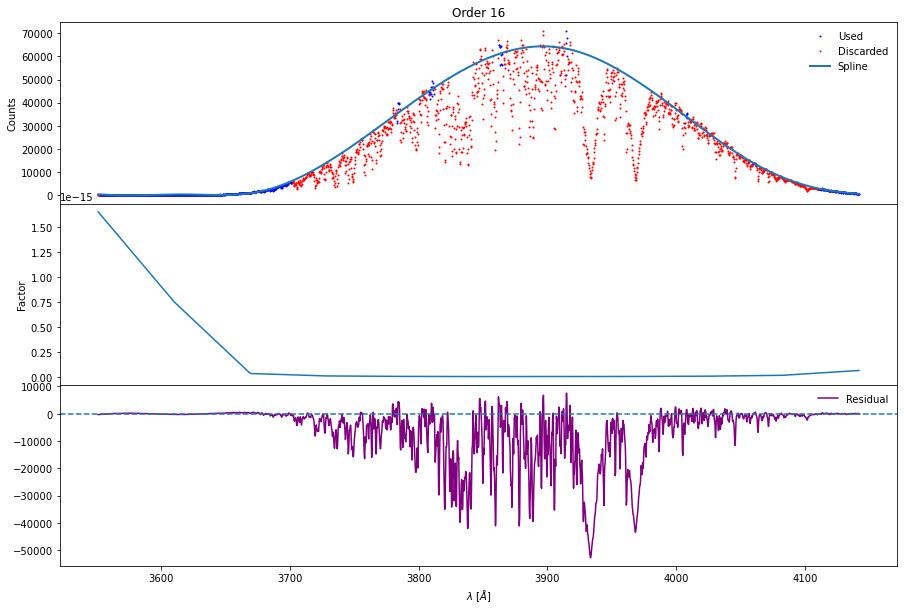

In [56]:
%matplotlib inline
fig, axs = plt.subplots(3, 1, figsize=(15, 10))
fig.subplots_adjust(hspace=0)

axs[0].plot(xltt16[mask16_ltt], yltt16[mask16_ltt], ls='', marker='.',
            markersize=2, label='Used', color='blue')
axs[0].plot(xltt16[np.logical_not(mask16_ltt)], yltt16[np.logical_not(mask16_ltt)],
            ls='', marker='.', markersize=2, label='Discarded', color='red')
axs[0].plot(ltt7379.wavelength(16), y_est_custom16_ltt, lw=2, label='Spline')
axs[0].legend(frameon=False)
axs[0].set_ylabel('Counts')
axs[0].set_title('Order 16')

axs[1].plot(simple_ltt7379.lda, factor16_ltt)
axs[1].set_ylabel('Factor')

axs[2].plot(ltt7379.wavelength(16), ltt7379.flux(16) - y_est_custom16_ltt,
            label='Residual', color='purple')
axs[2].legend(frameon=False)
axs[2].axhline(0, ls='--')
axs[2].set_xlabel(r'$\lambda$ [$\AA$]')

## Order 17

In [57]:
xltt17 = ltt7379.wavelength(17)
yltt17 = ltt7379.flux(17)

mask17_ltt = (xltt17 > 3342) * (xltt17 < 3483) + (xltt17 > 3537) * (xltt17 < 3540) \
          + (xltt17 > 3599.7) * (xltt17 < 3601.5) + (xltt17 > 3625) * (xltt17 < 3627) \
          + (xltt17 > 3658) * (xltt17 < 3659) + (xltt17 > 3698) * (xltt17 < 3700) \
          + (xltt17 > 3728.2) * (xltt17 < 3729.5) \
          + (xltt17 > 3783) * (xltt17 < 3785) \
          + (xltt17 > 3817) * (xltt17 < 3818) + (xltt17 > 3846)

knots17_ltt = np.array([3346, 3368, 3392, 3419, 3461, 3539.3, 3600, 3626, 3658.5, 3699, 3729,
                        3784, 3817.5, 3856, 3892])

In [58]:
model_custom17_ltt = get_natural_cubic_spline_model(x=xltt17[mask17_ltt],
                                                   y=yltt17[mask17_ltt],
                                                   minval=np.min(xltt17),
                                                   maxval=np.max(xltt17),
                                                   knots=knots17_ltt)
y_est_custom17_ltt = model_custom17_ltt.predict(ltt7379.wavelength(17))

In [59]:
obs_flux17_ltt = spectres(simple_ltt7379.lda, ltt7379.wavelength(17),
                         y_est_custom17_ltt, verbose=False)
factor17_ltt = reference_lttflux(simple_ltt7379.lda)/obs_flux17_ltt

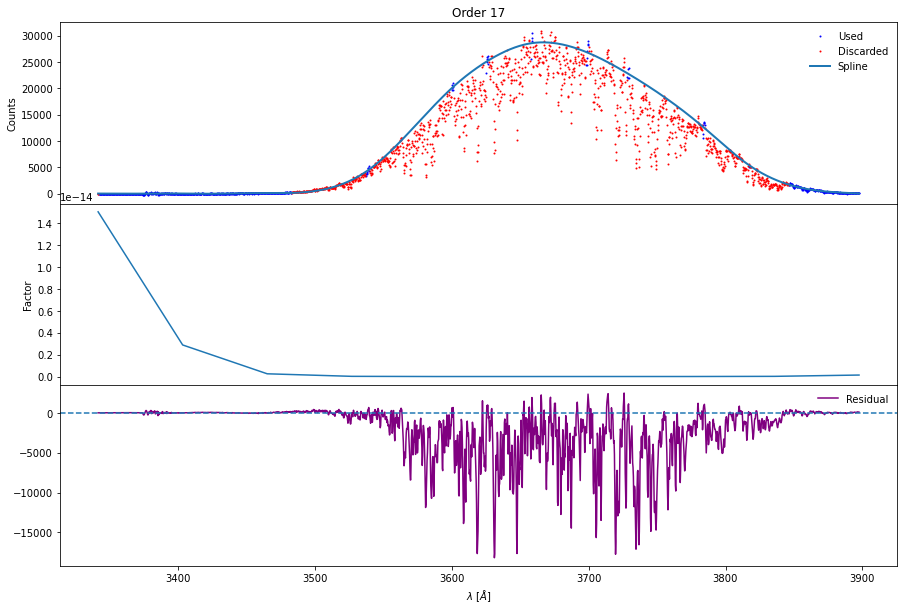

In [60]:
%matplotlib inline
fig, axs = plt.subplots(3, 1, figsize=(15, 10))
fig.subplots_adjust(hspace=0)

axs[0].plot(xltt17[mask17_ltt], yltt17[mask17_ltt], ls='', marker='.',
            markersize=2, label='Used', color='blue')
axs[0].plot(xltt17[np.logical_not(mask17_ltt)], yltt17[np.logical_not(mask17_ltt)],
            ls='', marker='.', markersize=2, label='Discarded', color='red')
axs[0].plot(ltt7379.wavelength(17), y_est_custom17_ltt, lw=2, label='Spline')
axs[0].legend(frameon=False)
axs[0].set_ylabel('Counts')
axs[0].set_title('Order 17')

axs[1].plot(simple_ltt7379.lda, factor17_ltt)
axs[1].set_ylabel('Factor')

axs[2].plot(ltt7379.wavelength(17), ltt7379.flux(17) - y_est_custom17_ltt,
            label='Residual', color='purple')
axs[2].legend(frameon=False)
axs[2].axhline(0, ls='--')
axs[2].set_xlabel(r'$\lambda$ [$\AA$]');

## Order 18

In [61]:
xltt18 = ltt7379.wavelength(18)[np.logical_and(ltt7379.wavelength(18) < 3679,
                                         ltt7379.wavelength(18) > 3265)]
yltt18 = ltt7379.flux(18)[np.logical_and(ltt7379.wavelength(18) < 3679,
                                         ltt7379.wavelength(18) > 3265)]

mask18_ltt = (xltt18 > 3286) * (xltt18 < 3355) \
          + (xltt18 < 3396) * (xltt18 > 3398) \
          + (xltt18 > 3419) * (xltt18 < 3421) \
          + (xltt18 > 3434) * (xltt18 < 3436) \
          + (xltt18 > 3469.8) * (xltt18 < 3470.9) \
          + (xltt18 > 3502.9) * (xltt18 < 3503.9) \
          + (xltt18 > 3561.9) * (xltt18 < 3563.7) \
          + (xltt18 > 3590)

knots18_ltt = np.array([3290, 3306, 3325, 3350, 3397,
                       3420, 3435, 3470, 3503, 3563,
                       3616, 3651, 3675])

In [62]:
model_custom18_ltt = get_natural_cubic_spline_model(x=xltt18[mask18_ltt],
                                                   y=yltt18[mask18_ltt],
                                                   minval=np.min(xltt18),
                                                   maxval=np.max(xltt18),
                                                   knots=knots18_ltt)
y_est_custom18_ltt = model_custom18_ltt.predict(ltt7379.wavelength(18))

In [63]:
obs_flux18_ltt = spectres(simple_ltt7379.lda, xltt18,
                         y_est_custom18_ltt, verbose=False)
factor18_ltt = reference_lttflux(simple_ltt7379.lda)/obs_flux18_ltt

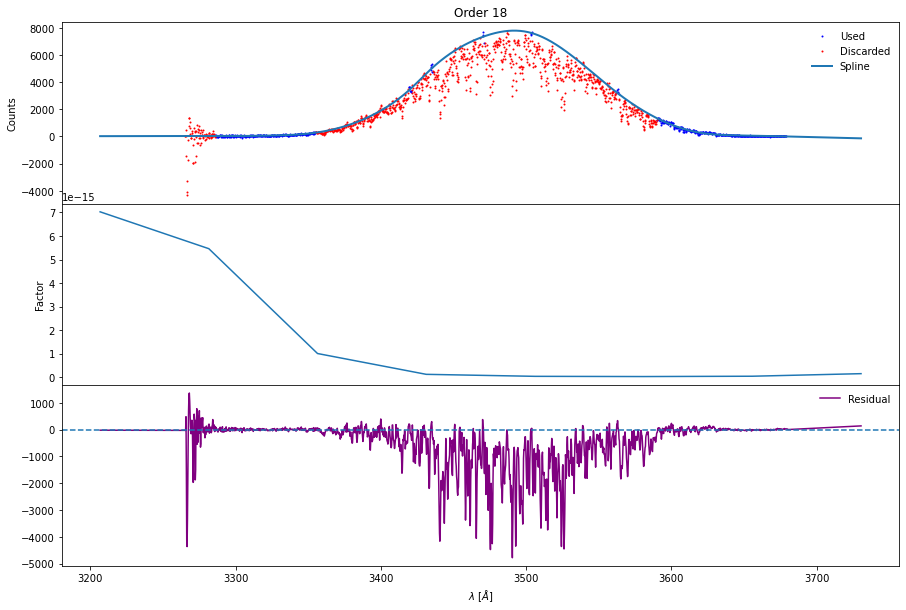

In [64]:
%matplotlib inline
fig, axs = plt.subplots(3, 1, figsize=(15, 10))
fig.subplots_adjust(hspace=0)

axs[0].plot(xltt18[mask18_ltt], yltt18[mask18_ltt], ls='', marker='.',
            markersize=2, label='Used', color='blue')
axs[0].plot(xltt18[np.logical_not(mask18_ltt)], yltt18[np.logical_not(mask18_ltt)],
            ls='', marker='.', markersize=2, label='Discarded', color='red')
axs[0].plot(ltt7379.wavelength(18), y_est_custom18_ltt, lw=2, label='Spline')
axs[0].legend(frameon=False)
axs[0].set_ylabel('Counts')
axs[0].set_title('Order 18')

axs[1].plot(simple_ltt7379.lda, factor18_ltt)
axs[1].set_ylabel('Factor')

axs[2].plot(ltt7379.wavelength(18), ltt7379.flux(18) - y_est_custom18_ltt, label='Residual', color='purple')
axs[2].legend(frameon=False)
axs[2].axhline(0, ls='--')
axs[2].set_xlabel(r'$\lambda$ [$\AA$]');

## Order 19

In [65]:
c19ltt = np.logical_and(ltt7379.wavelength(19) > 3186, ltt7379.wavelength(19) < 3452) 
yltt19 = ltt7379.flux(19)[c19ltt]
xltt19 = ltt7379.wavelength(19)[c19ltt]

mask19_ltt = (xltt19 < 3193) + (xltt19 > 3208) * (xltt19 < 3212) \
           + (xltt19 > 3236) * (xltt19 < 3239) + (xltt19 > 3268) * (xltt19 < 3270) \
           + (xltt19 > 3293.3) * (xltt19 < 3295) + (xltt19 > 3324.6) * (xltt19 < 3325.8) \
           + (xltt19 > 3351) * (xltt19 < 3355) + (xltt19 > 3378) * (xltt19 < 3476)

knots19_ltt = np.array([3189, 3210, 3237.5, 3269,
                       3294, 3325, 3353, 3380, 3418, 3446, 3468])

In [66]:
model_custom19_ltt = get_natural_cubic_spline_model(x=xltt19[mask19_ltt],
                                                y=yltt19[mask19_ltt],
                                                minval=np.min(xltt19),
                                                maxval=np.max(xltt19),
                                                knots=knots19_ltt)
y_est_custom19_ltt = model_custom19_ltt.predict(ltt7379.wavelength(19))

In [67]:
obs_flux19_ltt = spectres(simple_ltt7379.lda, xltt19,
                         y_est_custom19_ltt, verbose=False)
factor19_ltt = reference_lttflux(simple_ltt7379.lda)/obs_flux19_ltt

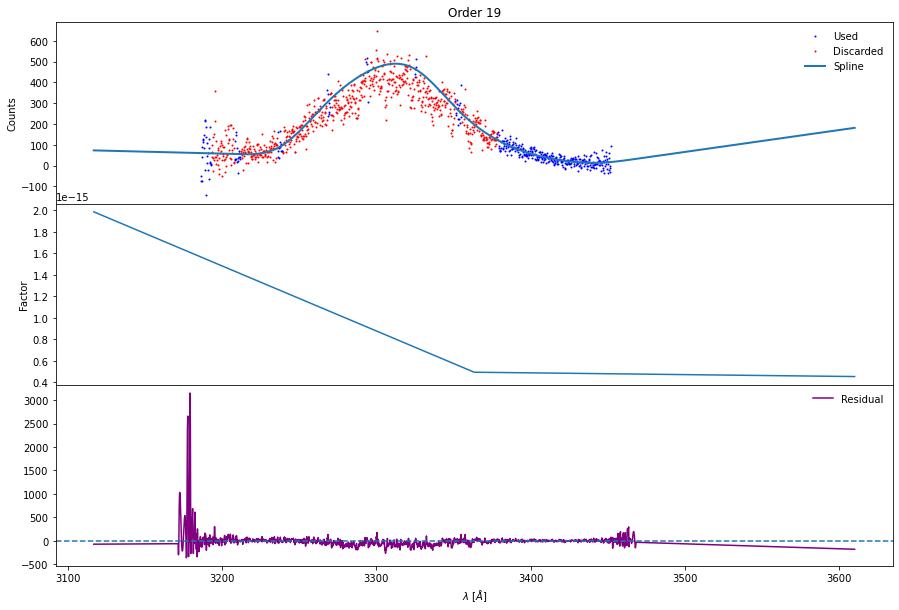

In [68]:
%matplotlib inline
fig, axs = plt.subplots(3, 1, figsize=(15, 10))
fig.subplots_adjust(hspace=0)

axs[0].plot(xltt19[mask19_ltt], yltt19[mask19_ltt],
            ls='', marker='.', markersize=2, label='Used', color='blue')
axs[0].plot(xltt19[np.logical_not(mask19_ltt)],
            yltt19[np.logical_not(mask19_ltt)],
            ls='', marker='.', markersize=2, label='Discarded', color='red')
axs[0].plot(ltt7379.wavelength(19), y_est_custom19_ltt, lw=2, label='Spline')
axs[0].legend(frameon=False)
axs[0].set_ylabel('Counts')
axs[0].set_title('Order 19')

axs[1].plot(simple_ltt7379.lda, factor19_ltt)
axs[1].set_ylabel('Factor')

axs[2].plot(ltt7379.wavelength(19), ltt7379.flux(19) - y_est_custom19_ltt,
            label='Residual', color='purple')
axs[2].legend(frameon=False)
axs[2].axhline(0, ls='--')
axs[2].set_xlabel(r'$\lambda$ [$\AA$]');

## Order 20

In [69]:
yltt20 = ltt7379.flux(20)[ltt7379.wavelength(20) < 3300]
xltt20 = ltt7379.wavelength(20)[ltt7379.wavelength(20) < 3300]

mask20_ltt = (xltt20 > 3060) * (xltt20 < 3260)

knots20_ltt = np.array([3062, 3093, 3100, 3150, 3187, 3220, 3249])

In [70]:
model_custom20_ltt = get_natural_cubic_spline_model(x=xltt20,
                                                 y=yltt20,
                                                 minval=np.min(xltt20),
                                                 maxval=np.max(xltt20),
                                                 knots=knots20_ltt)
y_est_custom20_ltt = model_custom20_ltt.predict(ltt7379.wavelength(20))

In [71]:
factor20_ltt = reference_lttflux(ltt7379.wavelength(20))/y_est_custom20_ltt

/tmp/ipykernel_479313/250620911.py:1: RuntimeWarning: divide by zero encountered in true_divide
  factor20_ltt = reference_lttflux(ltt7379.wavelength(20))/y_est_custom20_ltt


Text(0.5, 0, '$\\lambda$ [$\\AA$]')

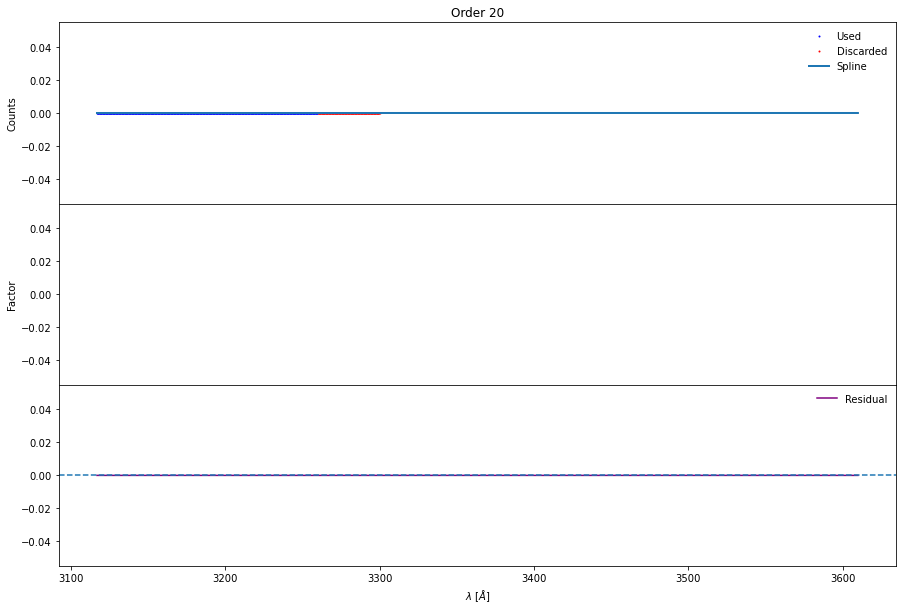

In [72]:
%matplotlib inline
fig, axs = plt.subplots(3, 1, figsize=(15, 10))
fig.subplots_adjust(hspace=0)

axs[0].plot(xltt20[mask20_ltt], yltt20[mask20_ltt], 
            ls='', marker='.', markersize=2, label='Used', color='blue')
axs[0].plot(xltt20[np.logical_not(mask20_ltt)], yltt20[np.logical_not(mask20_ltt)], 
            ls='', marker='.', markersize=2, label='Discarded', color='red')
axs[0].plot(ltt7379.wavelength(20), y_est_custom20_ltt, lw=2, label='Spline')
axs[0].legend(frameon=False)
axs[0].set_ylabel('Counts')
axs[0].set_title('Order 20')
#axs[0].set_xlim(3050, 3300)
#axs[0].set_ylim(-2000, 4000)

axs[1].plot(ltt7379.wavelength(20), factor20_ltt)
axs[1].set_ylabel('Factor')
#axs[1].set_xlim(3050, 3300)

axs[2].plot(ltt7379.wavelength(20), ltt7379.flux(20) - y_est_custom20_ltt, label='Residual', color='purple')
axs[2].legend(frameon=False)
axs[2].axhline(0, ls='--')
axs[2].set_xlabel(r'$\lambda$ [$\AA$]')
#axs[2].set_ylim(-2000, 2000)
#axs[2].set_xlim(3050, 3300)

In [73]:
simple_ltt7379.flux[:] = y_est_custom_model_ltt

In [74]:
spline_flux_ltt = [
    y_est_custom6_ltt,
    y_est_custom7_ltt,
    y_est_custom8_ltt,
    y_est_custom9_ltt,
    y_est_custom10_ltt,
    y_est_custom11_ltt,
    y_est_custom12_ltt,
    y_est_custom13_ltt,
    y_est_custom14_ltt,
    y_est_custom15_ltt,
    y_est_custom16_ltt,
    y_est_custom17_ltt,
    y_est_custom18_ltt,
    y_est_custom19_ltt,
    y_est_custom20_ltt
]

In [75]:
for i in range(6, 21):
    ltt7379.flux(i)[:] =  spline_flux_ltt[i - 6]
    print('Order {:} succesful for LTT'.format(i))

Order 6 succesful for LTT
Order 7 succesful for LTT
Order 8 succesful for LTT
Order 9 succesful for LTT
Order 10 succesful for LTT
Order 11 succesful for LTT
Order 12 succesful for LTT
Order 13 succesful for LTT
Order 14 succesful for LTT
Order 15 succesful for LTT
Order 16 succesful for LTT
Order 17 succesful for LTT
Order 18 succesful for LTT
Order 19 succesful for LTT
Order 20 succesful for LTT


# HR4963

## Order 6

In [76]:
xhr6 = hr4963.wavelength(6)
yhr6 = hr4963.flux(6)

mask6_hr = (xhr6 > 9504.07) * (xhr6 < 9515.8) + (xhr6 > 9648.6) * (xhr6 < 9651.8) \
          + (xhr6 > 9893) * (xhr6 < 9897) + (xhr6 > 10105)
knots6_hr = np.array([9510, 9650, 9895, 10050, 10200, 10400, 11000])

In [77]:
model_custom6_hr = get_natural_cubic_spline_model(x=xhr6[mask6_hr],
                                                  y=yhr6[mask6_hr],
                                                  minval=np.min(xhr6),
                                                  maxval=np.max(xhr6),
                                                  knots=knots6_hr)

y_est_custom6_hr = model_custom6_hr.predict(hr4963.wavelength(6))

In [78]:
obs_flux6_hr = spectres(simple_hr4963.lda, hr4963.wavelength(6), 
                     y_est_custom6_hr, verbose=False)

factor6_hr = reference_hrflux(simple_hr4963.lda)/obs_flux6_hr

Text(0.5, 0, '$\\lambda$ [$\\AA$]')

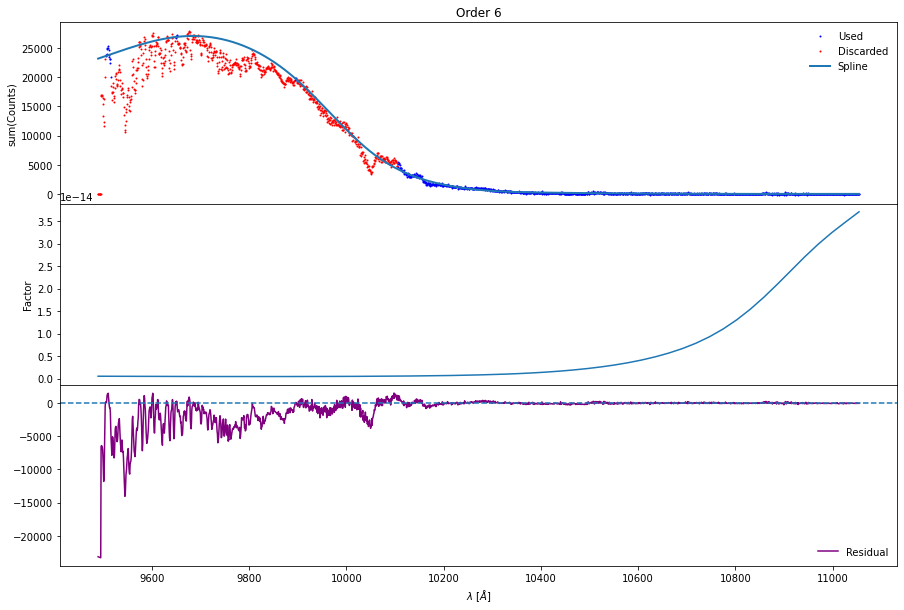

In [79]:
%matplotlib inline
fig, axs = plt.subplots(3, 1, figsize=(15, 10))
fig.subplots_adjust(hspace=0)

axs[0].plot(xhr6[mask6_hr], yhr6[mask6_hr], ls='', marker='.', markersize=2,
            label='Used', color='blue')
axs[0].plot(xhr6[np.logical_not(mask6_hr)], yhr6[np.logical_not(mask6_hr)],
            ls='', marker='.', markersize=2, label='Discarded', color='red')
axs[0].plot(hr4963.wavelength(6), y_est_custom6_hr, lw=2, label='Spline')
axs[0].legend(frameon=False)
axs[0].set_ylabel('sum(Counts)')
axs[0].set_title('Order 6')

axs[1].plot(simple_hr4963.lda, factor6_hr)
axs[1].set_ylabel('Factor')

axs[2].plot(hr4963.wavelength(6), hr4963.flux(6) - y_est_custom6_hr,
            label='Residual', color='purple')
axs[2].legend(frameon=False)
axs[2].axhline(0, ls='--')
axs[2].set_xlabel(r'$\lambda$ [$\AA$]')

## Order 7

In [80]:
xhr7 = hr4963.wavelength(7)
yhr7 = hr4963.flux(7)

mask7_hr = (xhr7 > 8170) * (xhr7 < 8174) + (xhr7 > 8409) * (xhr7 < 8412) \
         + (xhr7 > 8565) * (xhr7 < 8575) \
         + (xhr7 > 8622) * (xhr7 < 8643) + (xhr7 > 8782) * (xhr7 < 8800) \
         + (xhr7 > 8809) * (xhr7 < 8817) + (xhr7 > 8919) * (xhr7 < 8926) \
         + (xhr7 > 9049) * (xhr7 < 9057) + (xhr7 > 9193) * (xhr7 < 9208) \
         + (xhr7 > 9462) * (xhr7 < 9466)

knots7_hr = np.array([8172, 8411, 8630, 8630, 8790, 8813, 8923, 9053, 
                      9200, 9464])

In [81]:
model_custom7_hr = get_natural_cubic_spline_model(x=xhr7[mask7_hr], y=yhr7[mask7_hr], 
                                               minval=np.min(xhr7), maxval=np.max(xhr7), 
                                               knots=knots7_hr)

y_est_custom7_hr = model_custom7_hr.predict(hr4963.wavelength(7))

In [82]:
obs_flux7_hr = spectres(simple_hr4963.lda, hr4963.wavelength(7), 
                     y_est_custom7_hr, verbose=False)

factor7_hr = reference_hrflux(simple_hr4963.lda)/obs_flux7_hr

Text(0.5, 0, '$\\lambda$ [$\\AA$]')

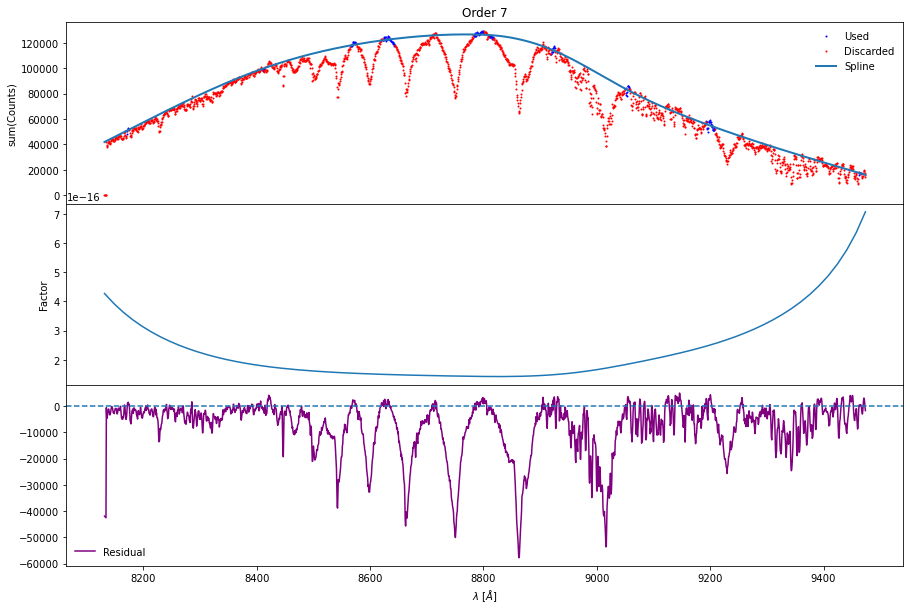

In [83]:
%matplotlib inline
fig, axs = plt.subplots(3, 1, figsize=(15, 10))
fig.subplots_adjust(hspace=0)

axs[0].plot(xhr7[mask7_hr], yhr7[mask7_hr], ls='', marker='.', markersize=2,
            label='Used', color='blue')
axs[0].plot(xhr7[np.logical_not(mask7_hr)], yhr7[np.logical_not(mask7_hr)],
            ls='', marker='.', markersize=2, label='Discarded', color='red')
#ax[0].errorbar(feige110.wavelength(6), feige110.flux(6), feige110.noise(6), ls='', marker='.', markersize=2, label='Observed')
axs[0].plot(hr4963.wavelength(7), y_est_custom7_hr, lw=2, label='Spline')
axs[0].legend(frameon=False)
axs[0].set_ylabel('sum(Counts)')
axs[0].set_title('Order 7')

axs[1].plot(simple_hr4963.lda, factor7_hr)
axs[1].set_ylabel('Factor')

axs[2].plot(hr4963.wavelength(7), hr4963.flux(7) - y_est_custom7_hr,
            label='Residual', color='purple')
axs[2].legend(frameon=False)
axs[2].axhline(0, ls='--')
axs[2].set_xlabel(r'$\lambda$ [$\AA$]')

## Order 8

In [84]:
yhr8_1 = hr4963.flux(8)[5:833]
xhr8_1 = hr4963.wavelength(8)[5:833]

yhr8_int = hr4963.flux(8)[833:1032]
xhr8_int = hr4963.wavelength(8)[833:1032]

yhr8_2 = hr4963.flux(8)[1032:]
xhr8_2 = hr4963.wavelength(8)[1032:]

mask8_1_hr = (xhr8_1 > 7123) * (xhr8_1 < 7144) \
           + (xhr8_1 > 7219) * (xhr8_1 < 7221) \
           + (xhr8_1 > 7378) * (xhr8_1 < 7380) \
           + (xhr8_1 > 7438) * (xhr8_1 < 7440) \
           + (xhr8_1 > 7499) * (xhr8_1 < 7504) \
           + (xhr8_1 > 7574) * (xhr8_1 < 7579)

mask8_2_hr = (xhr8_2 > 7737) * (xhr8_2 < 7739) \
           + (xhr8_2 > 7835) * (xhr8_2 < 7839) \
           + (xhr8_2 > 7912) * (xhr8_2 < 7914) \
           + (xhr8_2 > 8079) * (xhr8_2 < 8080) \
           + (xhr8_2 > 8245)

#x8 = feige110.flux(8)
#mask8 = (x8 > 7130) * (x8 < 7162) + (x8 > 7209) * (x8 < 7224) + (x8 > 7356) * (x8 < 7537) + (x8 > 7573) * (x8 < 7583) \
#      + (x8 > 7733) * (x8 < 7740) + (x8 > 7794) * (x8 < 8125) + (x8 > 8204) * (x8 < 8219) + (x8 > 8245) * (x8 < 8275)

knots8_1_hr = np.array([7130, 7220, 7379, 7439, 7502, 7577])
knots8_2_hr = np.array([7738, 7837, 7913, 8079.5, 8260, 8284])

In [85]:
model_custom8_1_hr = get_natural_cubic_spline_model(x=xhr8_1[mask8_1_hr],
                                                 y=yhr8_1[mask8_1_hr],
                                                 minval=np.min(xhr8_1),
                                                 maxval=np.max(xhr8_1),
                                                 knots=knots8_1_hr)
y_est_custom8_1_hr = model_custom8_1_hr.predict(hr4963.wavelength(8)[:833])

interp_y8_hr = interp1d(xhr8_int, yhr8_int, kind='linear', bounds_error=False, 
                     fill_value=np.nan, assume_sorted=True)
y_est_custom8_int_hr = interp_y8_hr(xhr8_int)

model_custom8_2_hr = get_natural_cubic_spline_model(x=xhr8_2[mask8_2_hr],
                                                 y=yhr8_2[mask8_2_hr],
                                                 minval=np.min(xhr8_2),
                                                 maxval=np.max(xhr8_2),
                                                 knots=knots8_2_hr)
y_est_custom8_2_hr = model_custom8_2_hr.predict(xhr8_2)

y_est_custom8_hr = np.concatenate((y_est_custom8_1_hr, y_est_custom8_int_hr, 
                                y_est_custom8_2_hr))

In [86]:
obs_flux8_hr = spectres(simple_hr4963.lda, hr4963.wavelength(8), 
                     y_est_custom8_hr, verbose=False)
factor8_hr = reference_hrflux(simple_hr4963.lda)/obs_flux8_hr

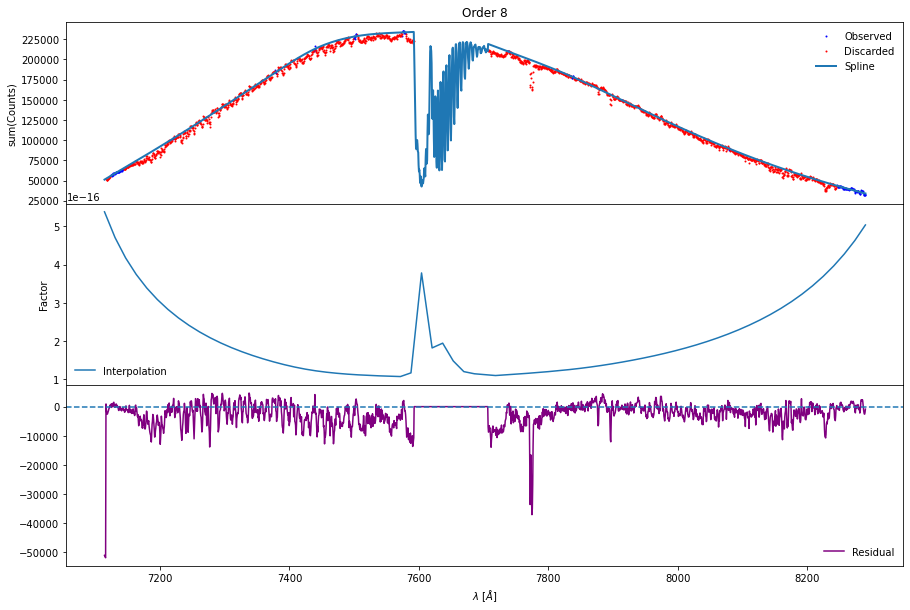

In [87]:
%matplotlib inline 
fig, axs = plt.subplots(3, 1, figsize=(15, 10))
fig.subplots_adjust(hspace=0)

axs[0].plot(xhr8_1[mask8_1_hr], yhr8_1[mask8_1_hr],
            ls='', marker='.', markersize=2, label='Observed', color='blue')
axs[0].plot(xhr8_2[mask8_2_hr], yhr8_2[mask8_2_hr],
            ls='', marker='.', markersize=2, color='blue')
axs[0].plot(xhr8_1[np.logical_not(mask8_1_hr)], yhr8_1[np.logical_not(mask8_1_hr)],
            ls='', marker='.', markersize=2, label='Discarded', color='red')
axs[0].plot(xhr8_2[np.logical_not(mask8_2_hr)], yhr8_2[np.logical_not(mask8_2_hr)],
            ls='', marker='.', markersize=2, color='red')
axs[0].plot(hr4963.wavelength(8), y_est_custom8_hr, lw=2, label='Spline')
axs[0].legend(frameon=False)
axs[0].set_ylabel('sum(Counts)')
axs[0].set_title('Order 8')

axs[1].plot(simple_hr4963.lda, factor8_hr, label='Interpolation')
axs[1].set_ylabel('Factor')
axs[1].legend(frameon=False)

axs[2].plot(hr4963.wavelength(8), hr4963.flux(8) - y_est_custom8_hr,
            label='Residual', color='purple')
axs[2].legend(frameon=False)
axs[2].axhline(0, ls='--')
axs[2].set_xlabel(r'$\lambda$ [$\AA$]');

## Order 9

In [88]:
yhr9_1 = hr4963.flux(9)[:1056]
xhr9_1 = hr4963.wavelength(9)[:1056]

yhr9_int = hr4963.flux(9)[1056:1218]
xhr9_int = hr4963.wavelength(9)[1056:1218]

yhr9_2 = hr4963.flux(9)[1218:]
xhr9_2 = hr4963.wavelength(9)[1218:]

mask9_1_hr = (xhr9_1 > 6329) * (xhr9_1 < 6460) + (xhr9_1 > 6608) * (xhr9_1 < 6611) \
           + (xhr9_1 > 6666) * (xhr9_1 < 6669) + (xhr9_1 > 6789) * (xhr9_1 < 6793) \
           + (xhr9_1 > 6855)

mask9_2_hr = (xhr9_2 > 6965) * (xhr9_2 < 6974) + (xhr9_2 > 7041) * (xhr9_2 < 7049) \
           + (xhr9_2 > 7112) * (xhr9_2 < 7119) + (xhr9_2 > 7321) * (xhr9_2 < 7360)

knots9_1_hr = np.array([6338, 6370, 6390, 6420, 6505, 6667, 6790, 6859])
knots9_2_hr = np.array([6970, 7045, 7116, 7350, 7359])

In [89]:
model_custom9_1_hr = get_natural_cubic_spline_model(x=xhr9_1[mask9_1_hr], 
                                                 y=yhr9_1[mask9_1_hr], 
                                                 minval=np.min(xhr9_1), 
                                                 maxval=np.max(xhr9_1), 
                                                 knots=knots9_1_hr)
y_est_custom9_1_hr = model_custom9_1_hr.predict(hr4963.wavelength(9)[:1056])

interp_y9_hr = interp1d(xhr9_int, yhr9_int, kind='linear', bounds_error=False, 
                     fill_value=np.nan, assume_sorted=True)
y_est_custom9_int_hr = interp_y9_hr(xhr9_int)

model_custom9_2_hr = get_natural_cubic_spline_model(x=xhr9_2[mask9_2_hr],
                                                 y=yhr9_2[mask9_2_hr],
                                                 minval=np.min(xhr9_2),
                                                 maxval=np.max(xhr9_2),
                                                 knots=knots9_2_hr)
y_est_custom9_2_hr = model_custom9_2_hr.predict(xhr9_2)

y_est_custom9_hr = np.concatenate((y_est_custom9_1_hr,
                                   y_est_custom9_int_hr, 
                                   y_est_custom9_2_hr))

In [90]:
obs_flux9_hr = spectres(simple_hr4963.lda, hr4963.wavelength(9), 
                     y_est_custom9_hr, verbose=False)
factor9_hr = reference_hrflux(simple_hr4963.lda)/obs_flux9_hr

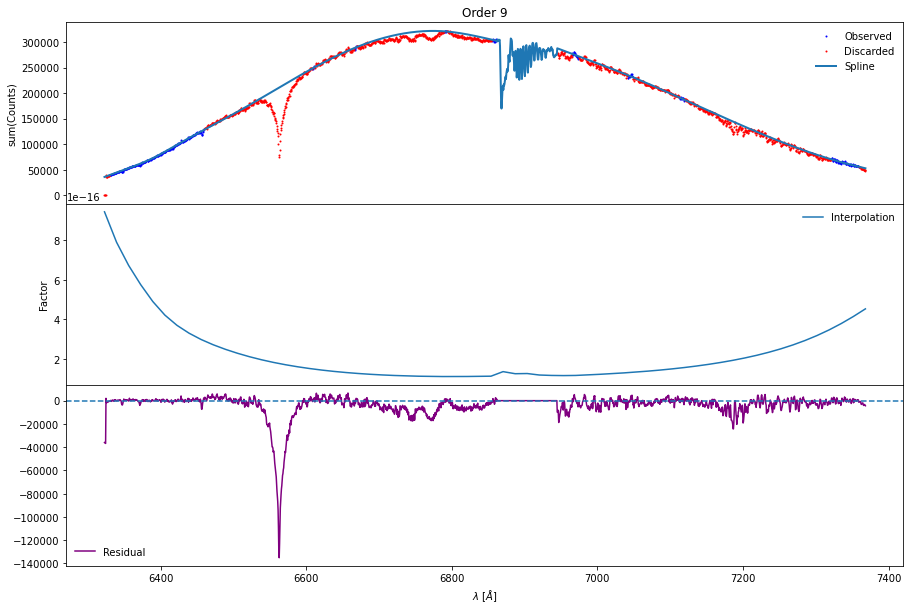

In [91]:
%matplotlib inline
fig, axs = plt.subplots(3, 1, figsize=(15, 10))
fig.subplots_adjust(hspace=0)

axs[0].plot(xhr9_1[mask9_1_hr], yhr9_1[mask9_1_hr],
            ls='', marker='.', markersize=2, label='Observed', color='blue')
axs[0].plot(xhr9_2[mask9_2_hr], yhr9_2[mask9_2_hr],
            ls='', marker='.', markersize=2, color='blue')
axs[0].plot(xhr9_1[np.logical_not(mask9_1_hr)], yhr9_1[np.logical_not(mask9_1_hr)],
            ls='', marker='.', markersize=2, label='Discarded', color='red')
axs[0].plot(xhr9_2[np.logical_not(mask9_2_hr)], yhr9_2[np.logical_not(mask9_2_hr)],
            ls='', marker='.', markersize=2, color='red')
axs[0].plot(hr4963.wavelength(9), y_est_custom9_hr, lw=2, label='Spline')
axs[0].legend(frameon=False)
axs[0].set_ylabel('sum(Counts)')
axs[0].set_title('Order 9')

axs[1].plot(simple_hr4963.lda, factor9_hr, label='Interpolation')
axs[1].set_ylabel('Factor')
axs[1].legend(frameon=False)

axs[2].plot(hr4963.wavelength(9), hr4963.flux(9) - y_est_custom9_hr,
            label='Residual', color='purple')
axs[2].legend(frameon=False)
axs[2].axhline(0, ls='--')
axs[2].set_xlabel(r'$\lambda$ [$\AA$]');

## Order 10

In [92]:
yhr10 = hr4963.flux(10)
xhr10 = hr4963.wavelength(10)

mask10_hr = (xhr10 > 5692) * (xhr10 < 5873) + (xhr10 > 5997) * (xhr10 < 5999) \
          + (xhr10 > 6113) * (xhr10 < 6115) + (xhr10 > 6200) * (xhr10 < 6210) \
          + (xhr10 > 6271) * (xhr10 < 6275) + (xhr10 > 6397) * (xhr10 < 6400) \
          + (xhr10 > 6616) * (xhr10 < 6625)

knots10_hr = np.array([5698, 5710, 5758, 5829, 5998, 6114, 6205, 6273, 6398, 
                        6600, 6620])

In [93]:
model_custom10_hr = get_natural_cubic_spline_model(x=xhr10[mask10_hr],
                                                y=yhr10[mask10_hr],
                                                minval=np.min(xhr10),
                                                maxval=np.max(xhr10),
                                                knots=knots10_hr)
y_est_custom10_hr = model_custom10_hr.predict(hr4963.wavelength(10))

In [94]:
obs_flux10_hr = spectres(simple_hr4963.lda, hr4963.wavelength(10), 
                      y_est_custom10_hr, verbose=False)
factor10_hr = reference_hrflux(simple_hr4963.lda)/obs_flux10_hr

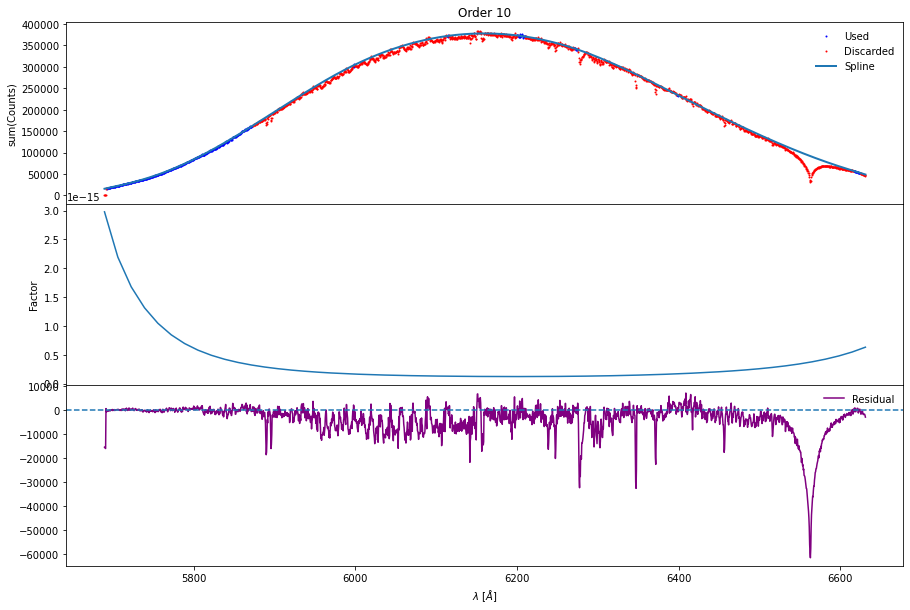

In [95]:
%matplotlib inline
fig, axs = plt.subplots(3, 1, figsize=(15, 10))
fig.subplots_adjust(hspace=0)

axs[0].plot(xhr10[mask10_hr], yhr10[mask10_hr], ls='', marker='.',
            markersize=2, label='Used', color='blue')
axs[0].plot(xhr10[np.logical_not(mask10_hr)], yhr10[np.logical_not(mask10_hr)],
            ls='', marker='.', markersize=2, label='Discarded', color='red')
axs[0].plot(hr4963.wavelength(10), y_est_custom10_hr, lw=2, label='Spline')
axs[0].legend(frameon=False)
axs[0].set_ylabel('sum(Counts)')
axs[0].set_title('Order 10')

axs[1].plot(simple_hr4963.lda, factor10_hr)
axs[1].set_ylabel('Factor')

axs[2].plot(hr4963.wavelength(10), hr4963.flux(10) - y_est_custom10_hr,
            label='Residual', color='purple')
axs[2].legend(frameon=False)
axs[2].axhline(0, ls='--')
axs[2].set_xlabel(r'$\lambda$ [$\AA$]');

## Order 11

In [96]:
xhr11 = hr4963.wavelength(11)
yhr11 = hr4963.flux(11)

mask11_hr = (xhr11 > 5174) * (xhr11 < 5280) + (xhr11 > 5351) * (xhr11 < 5361) \
          + (xhr11 > 5457) * (xhr11 < 5461) + (xhr11 > 5536) * (xhr11 < 5541) \
          + (xhr11 > 5644) * (xhr11 < 5648) \
          + (xhr11 > 5742) * (xhr11 < 5745) + (xhr11 > 5819) * (xhr11 < 5871) \
          + (xhr11 > 5904)

knots11_hr = np.array([5183, 5233, 5356, 5458, 5538, 
                        5646, 5743, 5845, 5908, 5940,
                        5978, 6021])

In [97]:
model_custom11_hr = get_natural_cubic_spline_model(x=xhr11[mask11_hr],
                                                   y=yhr11[mask11_hr],
                                                   minval=np.min(xhr11),
                                                   maxval=np.max(xhr11),
                                                   knots=knots11_hr)
y_est_custom11_hr = model_custom11_hr.predict(hr4963.wavelength(11))

In [98]:
obs_flux11_hr = spectres(simple_hr4963.lda, hr4963.wavelength(11), 
                      y_est_custom11_hr, verbose=False)
factor11_hr = reference_hrflux(simple_hr4963.lda)/obs_flux11_hr

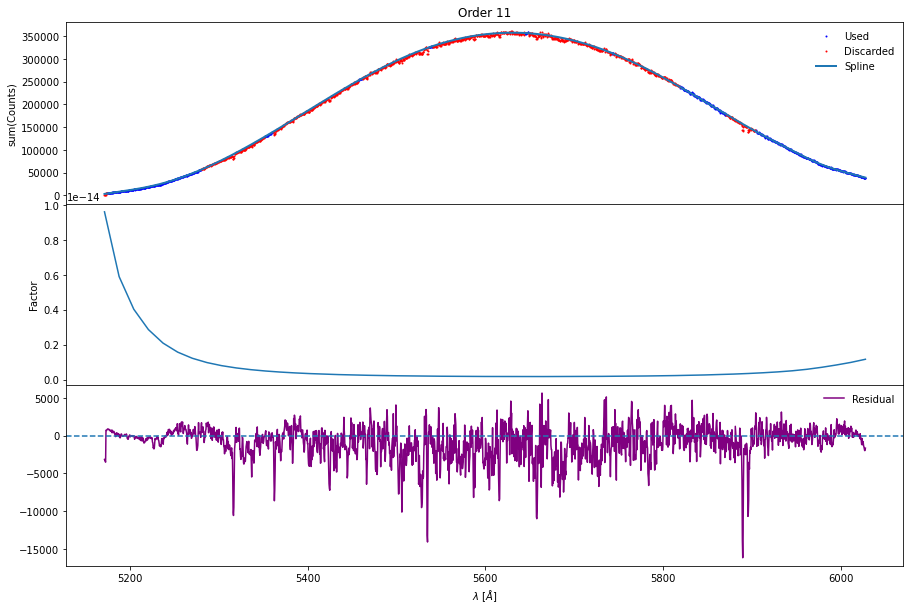

In [99]:
%matplotlib inline
fig, axs = plt.subplots(3, 1, figsize=(15, 10))
fig.subplots_adjust(hspace=0)

axs[0].plot(xhr11[mask11_hr], yhr11[mask11_hr],
            ls='', marker='.', markersize=2, label='Used', color='blue')
axs[0].plot(xhr11[np.logical_not(mask11_hr)], yhr11[np.logical_not(mask11_hr)],
            ls='', marker='.', markersize=2, label='Discarded', color='red')
axs[0].plot(hr4963.wavelength(11), y_est_custom11_hr, lw=2, label='Spline')
axs[0].legend(frameon=False)
axs[0].set_ylabel('sum(Counts)')
axs[0].set_title('Order 11')

axs[1].plot(simple_hr4963.lda, factor11_hr)
axs[1].set_ylabel('Factor')

axs[2].plot(hr4963.wavelength(11), hr4963.flux(11) - y_est_custom11_hr,
            label='Residual', color='purple')
axs[2].legend(frameon=False)
axs[2].axhline(0, ls='--')
axs[2].set_xlabel(r'$\lambda$ [$\AA$]');

## Order 12

In [100]:
yhr12 = hr4963.flux(12)
xhr12 = hr4963.wavelength(12)

mask12_hr = (xhr12 > 4740) * (xhr12 < 4838) + (xhr12 > 4913) * (xhr12 < 4916) \
           + (xhr12 > 4986) * (xhr12 < 4988) + (xhr12 > 5031) * (xhr12 < 5034) \
           + (xhr12 > 5085) * (xhr12 < 5087) \
           + (xhr12 > 5156) * (xhr12 < 5160) + (xhr12 > 5255) * (xhr12 < 5258) \
           + (xhr12 > 5354) * (xhr12 < 5360) + (xhr12 > 5420)

knots12_hr = np.array([4750, 4800, 4914, 4987, 5033,
                    5086, 5158, 5256, 5357,
                    5440, 5470, 5520])

In [101]:
model_custom12_hr = get_natural_cubic_spline_model(x=xhr12[mask12_hr],
                                                y=yhr12[mask12_hr],
                                                minval=np.min(xhr12),
                                                maxval=np.max(xhr12),
                                                knots=knots12_hr)
y_est_custom12_hr = model_custom12_hr.predict(hr4963.wavelength(12))

In [102]:
obs_flux12_hr = spectres(simple_hr4963.lda, hr4963.wavelength(12), 
                      y_est_custom12_hr, verbose=False)
factor12_hr = reference_hrflux(simple_hr4963.lda)/obs_flux12_hr

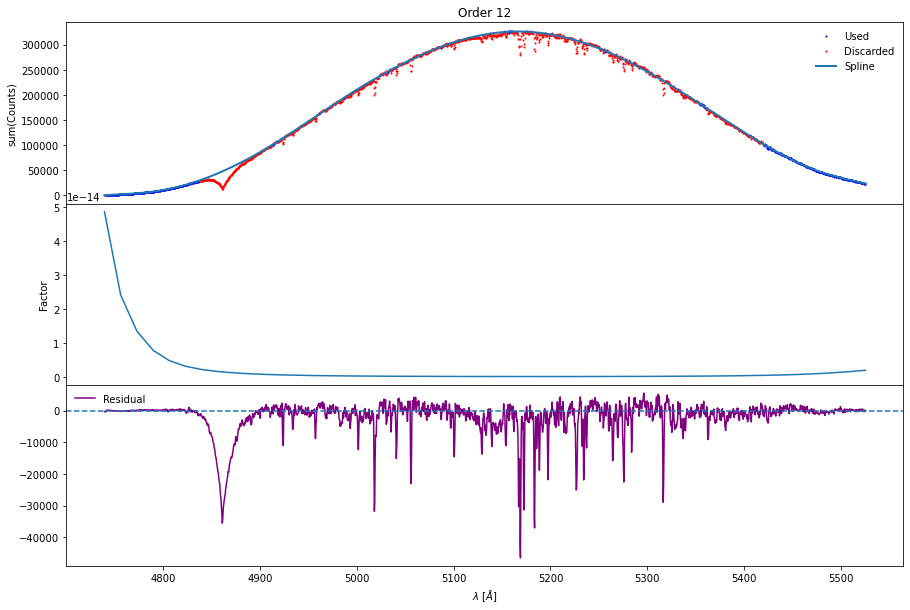

In [103]:
%matplotlib inline
fig, axs = plt.subplots(3, 1, figsize=(15, 10))
fig.subplots_adjust(hspace=0)

axs[0].plot(xhr12[mask12_hr], yhr12[mask12_hr], ls='',
            marker='.', markersize=2, label='Used', color='blue')
axs[0].plot(xhr12[np.logical_not(mask12_hr)], yhr12[np.logical_not(mask12_hr)],
            ls='', marker='.', markersize=2, label='Discarded', color='red')
axs[0].plot(hr4963.wavelength(12), y_est_custom12_hr, lw=2, label='Spline')
axs[0].legend(frameon=False)
axs[0].set_ylabel('sum(Counts)')
axs[0].set_title('Order 12')

axs[1].plot(simple_hr4963.lda, factor12_hr)
axs[1].set_ylabel('Factor')

axs[2].plot(hr4963.wavelength(12), hr4963.flux(12) - y_est_custom12_hr,
            label='Residual', color='purple')
axs[2].legend(frameon=False)
axs[2].axhline(0, ls='--')
axs[2].set_xlabel(r'$\lambda$ [$\AA$]');

## Order 13

In [104]:
yhr13 = hr4963.flux(13)
xhr13 = hr4963.wavelength(13)

mask13_hr = (xhr13 > 4376) * (xhr13 < 4468) + (xhr13 > 4475) * (xhr13 < 4524) \
          + (xhr13 > 4574) * (xhr13 < 4576) + (xhr13 > 4657) * (xhr13 < 4661) \
          + (xhr13 > 4723) * (xhr13 < 4726) + (xhr13 > 4773) * (xhr13 < 4777) \
          + (xhr13 > 4816) * (xhr13 < 4819) + (xhr13 > 4961)

knots13_hr = np.array([4379, 4429, 4486, 4520, 4575, 4659, 4725, 4775, 4818,
                        4962, 5016, 5051, 5091])

In [105]:
model_custom13_hr = get_natural_cubic_spline_model(x=xhr13[mask13_hr],
                                                y=yhr13[mask13_hr],
                                                minval=np.min(xhr13),
                                                maxval=np.max(xhr13),
                                                knots=knots13_hr)
y_est_custom13_hr = model_custom13_hr.predict(hr4963.wavelength(13))

In [106]:
obs_flux13_hr = spectres(simple_hr4963.lda, hr4963.wavelength(13),
                      y_est_custom13_hr, verbose=False)
factor13_hr = reference_hrflux(simple_hr4963.lda)/obs_flux13_hr

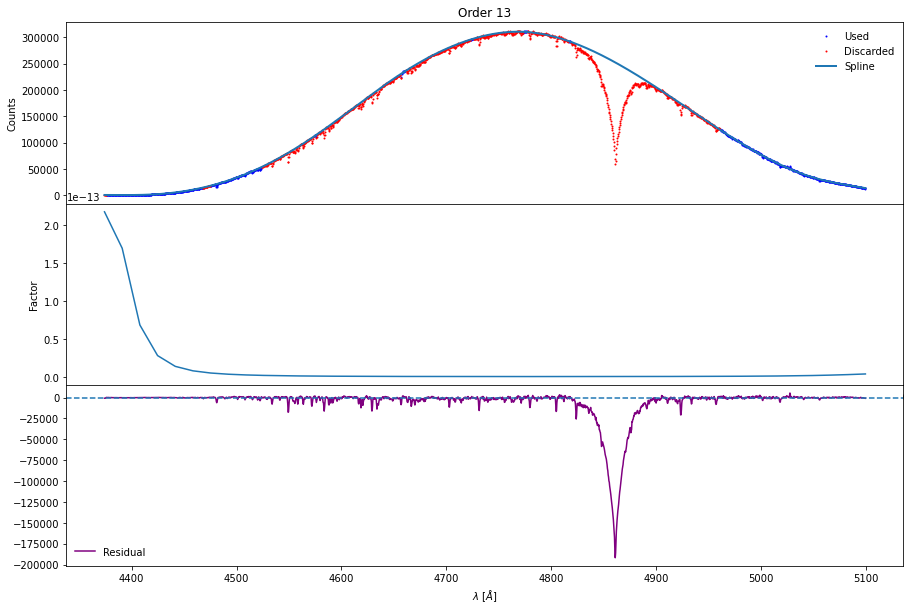

In [107]:
%matplotlib inline
fig, axs = plt.subplots(3, 1, figsize=(15, 10))
fig.subplots_adjust(hspace=0)

axs[0].plot(xhr13[mask13_hr], yhr13[mask13_hr], ls='',
            marker='.', markersize=2, label='Used', color='blue')
axs[0].plot(xhr13[np.logical_not(mask13_hr)], yhr13[np.logical_not(mask13_hr)],
            ls='', marker='.', markersize=2, label='Discarded', color='red')
#axs[0].errorbar(feige110.wavelength(13), feige110.flux(13), feige110.noise(13), ls='', marker='.', markersize=2, label='Observed')
axs[0].plot(hr4963.wavelength(13), y_est_custom13_hr, lw=2, label='Spline')
axs[0].legend(frameon=False)
axs[0].set_ylabel('Counts')
axs[0].set_title('Order 13')

axs[1].plot(simple_hr4963.lda, factor13_hr)
axs[1].set_ylabel('Factor')

axs[2].plot(hr4963.wavelength(13), hr4963.flux(13) - y_est_custom13_hr, 
            label='Residual', color='purple')
axs[2].legend(frameon=False)
axs[2].axhline(0, ls='--')
axs[2].set_xlabel(r'$\lambda$ [$\AA$]');

## Order 14

In [108]:
yhr14 = hr4963.flux(14)
xhr14 = hr4963.wavelength(14)

mask14_hr = (xhr14 > 4062) * (xhr14 < 4221) + (xhr14 > 4291) * (xhr14 < 4293) \
          + (xhr14 > 4418) * (xhr14 < 4421) + (xhr14 > 4476) * (xhr14 < 4478) \
          + (xhr14 > 4530) * (xhr14 < 4533) + (xhr14 > 4573) * (xhr14 < 4678) \
          + (xhr14 > 4692)

knots14_hr = np.array([4068, 4127, 4142, 4292, 4419,
                        4477, 4531, 4614, 4646, 4701, 4729])

In [109]:
model_custom14_hr = get_natural_cubic_spline_model(x=xhr14[mask14_hr], 
                                                y=yhr14[mask14_hr], 
                                                minval=np.min(xhr14), 
                                                maxval=np.max(xhr14), 
                                                knots=knots14_hr)
y_est_custom14_hr = model_custom14_hr.predict(hr4963.wavelength(14))

In [110]:
obs_flux14_hr = spectres(simple_hr4963.lda, hr4963.wavelength(14),
                         y_est_custom14_hr, verbose=False)
factor14_hr = reference_hrflux(simple_hr4963.lda)/obs_flux14_hr

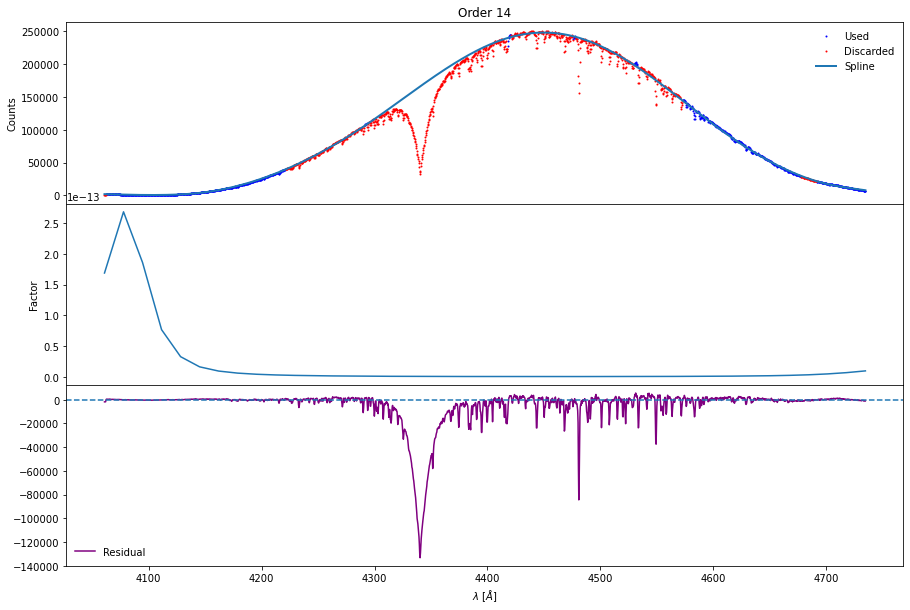

In [111]:
%matplotlib inline
fig, axs = plt.subplots(3, 1, figsize=(15, 10))
fig.subplots_adjust(hspace=0)

axs[0].plot(xhr14[mask14_hr], yhr14[mask14_hr], ls='', marker='.',
            markersize=2, label='Used', color='blue')
axs[0].plot(xhr14[np.logical_not(mask14_hr)], yhr14[np.logical_not(mask14_hr)], ls='',
            marker='.', markersize=2, label='Discarded', color='red')
axs[0].plot(hr4963.wavelength(14), y_est_custom14_hr, lw=2, label='Spline')
axs[0].legend(frameon=False)
axs[0].set_ylabel('Counts')
axs[0].set_title('Order 14')

axs[1].plot(simple_hr4963.lda, factor14_hr)
axs[1].set_ylabel('Factor')

axs[2].plot(hr4963.wavelength(14), hr4963.flux(14) - y_est_custom14_hr,
            label='Residual', color='purple')
axs[2].legend(frameon=False)
axs[2].axhline(0, ls='--')
axs[2].set_xlabel(r'$\lambda$ [$\AA$]');

## Order 15

In [112]:
yhr15 = hr4963.flux(15)
xhr15 = hr4963.wavelength(15)

mask15_hr = (xhr15 > 3790) * (xhr15 < 3917) + (xhr15 > 3945) * (xhr15 < 3955) \
          + (xhr15 > 4001) * (xhr15 < 4003) + (xhr15 > 4059) * (xhr15 < 4062) \
          + (xhr15 > 4135) * (xhr15 < 4141) + (xhr15 > 4164) * (xhr15 < 4166) \
          + (xhr15 > 4192) * (xhr15 < 4194) + (xhr15 > 4262) * (xhr15 < 4266) \
          + (xhr15 > 4315) * (xhr15 < 4321) + (xhr15 > 4357)

knots15_hr = np.array([3797, 3840, 3876, 3891, 3950, 4002, 4060,
                        4138, 4165, 4193, 4264, 4320, 4367, 4402])

In [113]:
model_custom15_hr = get_natural_cubic_spline_model(x=xhr15[mask15_hr],
                                                y=yhr15[mask15_hr],
                                                minval=np.min(xhr15),
                                                maxval=np.max(xhr15),
                                                knots=knots15_hr)
y_est_custom15_hr = model_custom15_hr.predict(hr4963.wavelength(15))

In [114]:
obs_flux15_hr = spectres(simple_hr4963.lda, hr4963.wavelength(15),
                      y_est_custom15_hr, verbose=False)
factor15_hr = reference_hrflux(simple_hr4963.lda)/obs_flux15_hr

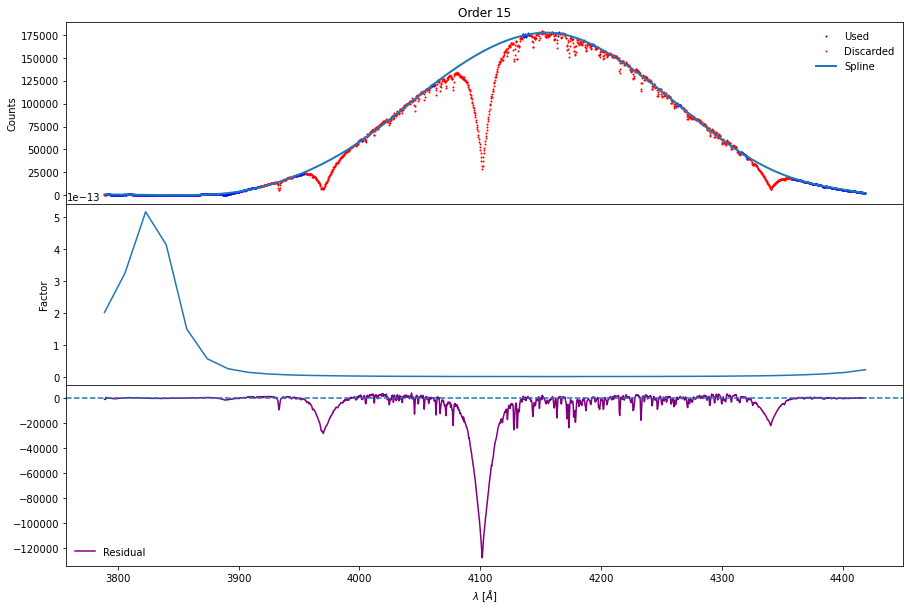

In [115]:
%matplotlib inline
fig, axs = plt.subplots(3, 1, figsize=(15, 10))
fig.subplots_adjust(hspace=0)

axs[0].plot(xhr15[mask15_hr], yhr15[mask15_hr], ls='', marker='.',
            markersize=2, label='Used', color='blue')
axs[0].plot(xhr15[np.logical_not(mask15_hr)], yhr15[np.logical_not(mask15_hr)],
            ls='', marker='.', markersize=2, label='Discarded', color='red')
axs[0].plot(hr4963.wavelength(15), y_est_custom15_hr, lw=2, label='Spline')
axs[0].legend(frameon=False)
axs[0].set_ylabel('Counts')
axs[0].set_title('Order 15')

axs[1].plot(simple_hr4963.lda, factor15_hr)
axs[1].set_ylabel('Factor')

axs[2].plot(hr4963.wavelength(15), hr4963.flux(15) - y_est_custom15_hr,
            label='Residual', color='purple')
axs[2].legend(frameon=False)
axs[2].axhline(0, ls='--')
axs[2].set_xlabel(r'$\lambda$ [$\AA$]');

## Order 16

In [116]:
yhr16 = hr4963.flux(16)
xhr16 = hr4963.wavelength(16)

mask16_hr = (xhr16 > 3552) * (xhr16 < 3702)  \
          + (xhr16 > 3783) * (xhr16 < 3785) + (xhr16 > 3808) * (xhr16 < 3812) \
          + (xhr16 > 3862) * (xhr16 < 3865) + (xhr16 > 3922) * (xhr16 < 3923) \
          + (xhr16 > 4007) * (xhr16 < 4008.5) \
          + (xhr16 > 4059) * (xhr16 < 4062) + (xhr16 > 4110)

knots16_hr = np.array([3554, 3561, 3618, 3677, 3784, 3811, 3863, 3922.5,
                        4008, 4060, 4120, 4138])

In [117]:
model_custom16_hr = get_natural_cubic_spline_model(x=xhr16[mask16_hr],
                                                y=yhr16[mask16_hr],
                                                minval=np.min(xhr16),
                                                maxval=np.max(xhr16),
                                                knots=knots16_hr)
y_est_custom16_hr = model_custom16_hr.predict(hr4963.wavelength(16))

In [118]:
obs_flux16_hr = spectres(simple_hr4963.lda, hr4963.wavelength(16),
                      y_est_custom16_hr, verbose=False)
factor16_hr = reference_lttflux(simple_hr4963.lda)/obs_flux16_hr

Text(0.5, 0, '$\\lambda$ [$\\AA$]')

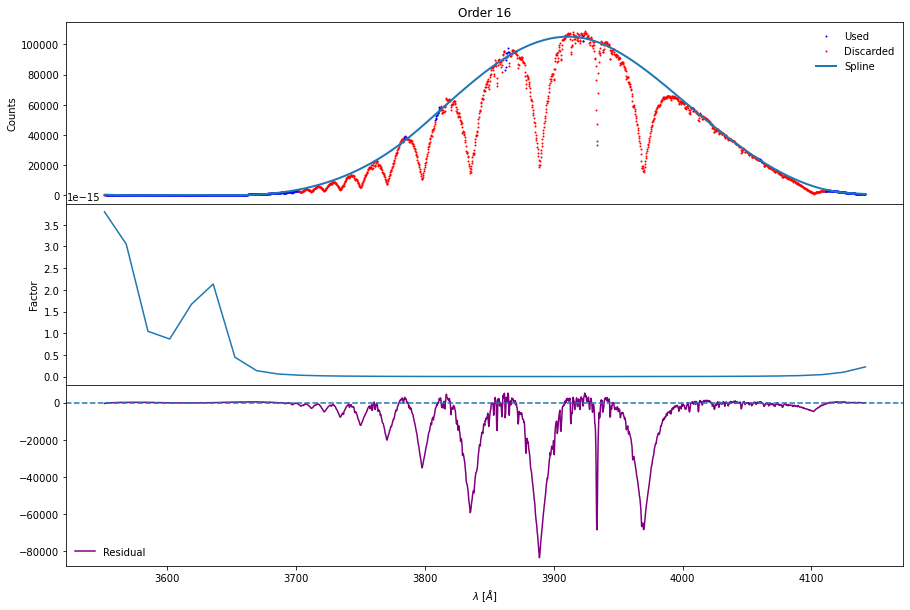

In [119]:
%matplotlib inline
fig, axs = plt.subplots(3, 1, figsize=(15, 10))
fig.subplots_adjust(hspace=0)

axs[0].plot(xhr16[mask16_hr], yhr16[mask16_hr], ls='', marker='.',
            markersize=2, label='Used', color='blue')
axs[0].plot(xhr16[np.logical_not(mask16_hr)], yhr16[np.logical_not(mask16_hr)],
            ls='', marker='.', markersize=2, label='Discarded', color='red')
axs[0].plot(hr4963.wavelength(16), y_est_custom16_hr, lw=2, label='Spline')
axs[0].legend(frameon=False)
axs[0].set_ylabel('Counts')
axs[0].set_title('Order 16')

axs[1].plot(simple_hr4963.lda, factor16_hr)
axs[1].set_ylabel('Factor')

axs[2].plot(hr4963.wavelength(16), hr4963.flux(16) - y_est_custom16_hr,
            label='Residual', color='purple')
axs[2].legend(frameon=False)
axs[2].axhline(0, ls='--')
axs[2].set_xlabel(r'$\lambda$ [$\AA$]')

## Order 17

In [120]:
xhr17 = hr4963.wavelength(17)
yhr17 = hr4963.flux(17)

mask17_hr = (xhr17 > 3342) * (xhr17 < 3483) + (xhr17 > 3537) * (xhr17 < 3540) \
          + (xhr17 > 3599.7) * (xhr17 < 3601.5) + (xhr17 > 3625) * (xhr17 < 3627) \
          + (xhr17 > 3674) * (xhr17 < 3675) + (xhr17 > 3693) * (xhr17 < 3695) \
          + (xhr17 > 3728.2) * (xhr17 < 3729.5) \
          + (xhr17 > 3783) * (xhr17 < 3785) \
          + (xhr17 > 3817) * (xhr17 < 3818) + (xhr17 > 3846)

knots17_hr = np.array([3346, 3368, 3392, 3419, 3461, 3539.3, 3600, 3626, 3674.5, 3694, 3729,
                        3784, 3817.5, 3856, 3892])

In [121]:
model_custom17_hr = get_natural_cubic_spline_model(x=xhr17[mask17_hr],
                                                   y=yhr17[mask17_hr],
                                                   minval=np.min(xhr17),
                                                   maxval=np.max(xhr17),
                                                   knots=knots17_hr)
y_est_custom17_hr = model_custom17_hr.predict(hr4963.wavelength(17))

In [122]:
obs_flux17_hr = spectres(simple_hr4963.lda, hr4963.wavelength(17),
                         y_est_custom17_hr, verbose=False)
factor17_hr = reference_hrflux(simple_hr4963.lda)/obs_flux17_hr

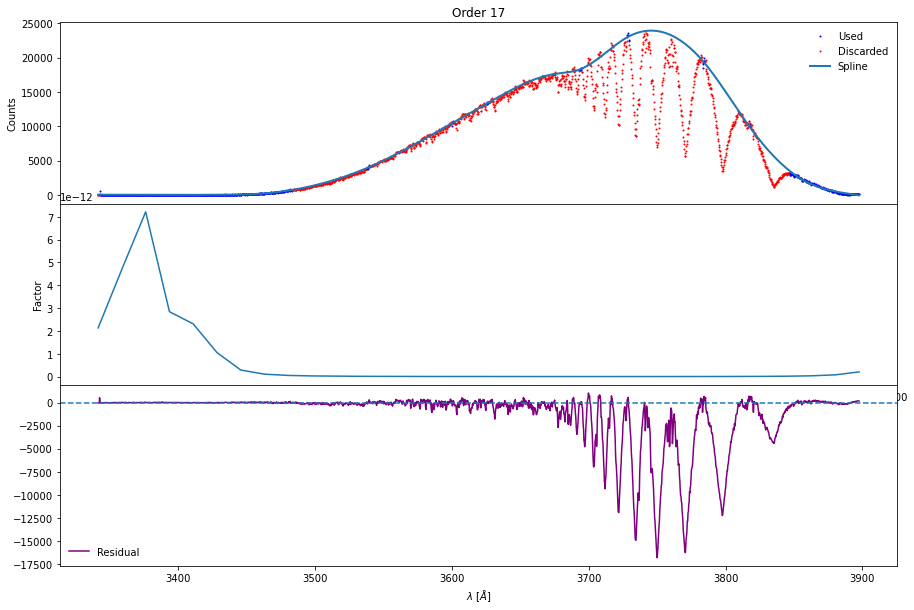

In [123]:
%matplotlib inline
fig, axs = plt.subplots(3, 1, figsize=(15, 10))
fig.subplots_adjust(hspace=0)

axs[0].plot(xhr17[mask17_hr], yhr17[mask17_hr], ls='', marker='.',
            markersize=2, label='Used', color='blue')
axs[0].plot(xhr17[np.logical_not(mask17_hr)], yhr17[np.logical_not(mask17_hr)],
            ls='', marker='.', markersize=2, label='Discarded', color='red')
axs[0].plot(hr4963.wavelength(17), y_est_custom17_hr, lw=2, label='Spline')
axs[0].legend(frameon=False)
axs[0].set_ylabel('Counts')
axs[0].set_title('Order 17')

axs[1].plot(simple_hr4963.lda, factor17_hr)
axs[1].set_ylabel('Factor')

axs[2].plot(hr4963.wavelength(17), hr4963.flux(17) - y_est_custom17_hr,
            label='Residual', color='purple')
axs[2].legend(frameon=False)
axs[2].axhline(0, ls='--')
axs[2].set_xlabel(r'$\lambda$ [$\AA$]');

## Order 18

In [128]:
xhr18 = hr4963.wavelength(18)[np.logical_and(hr4963.wavelength(18) < 3679,
                                         hr4963.wavelength(18) > 3265)]
yhr18 = hr4963.flux(18)[np.logical_and(hr4963.wavelength(18) < 3679,
                                         hr4963.wavelength(18) > 3265)]

mask18_hr = (xhr18 > 3286) * (xhr18 < 3355) \
          + (xhr18 < 3396) * (xhr18 > 3398) \
          + (xhr18 > 3419) * (xhr18 < 3421) \
          + (xhr18 > 3434) * (xhr18 < 3436) \
          + (xhr18 > 3469.8) * (xhr18 < 3470.9) \
          + (xhr18 > 3502.9) * (xhr18 < 3503.9) \
          + (xhr18 > 3561.9) * (xhr18 < 3563.7) \
          + (xhr18 > 3590)

knots18_hr = np.array([3290, 3306, 3325, 3350, 3397,
                       3420, 3435, 3470, 3503, 3563,
                       3616, 3651, 3675])

In [129]:
model_custom18_hr = get_natural_cubic_spline_model(x=xhr18[mask18_hr],
                                                   y=yhr18[mask18_hr],
                                                   minval=np.min(xhr18),
                                                   maxval=np.max(xhr18),
                                                   knots=knots18_hr)
y_est_custom18_hr = model_custom18_hr.predict(hr4963.wavelength(18))

In [130]:
obs_flux18_hr = spectres(simple_hr4963.lda, xhr18,
                         y_est_custom18_hr, verbose=False)
factor18_hr = reference_hrflux(simple_hr4963.lda)/obs_flux18_hr

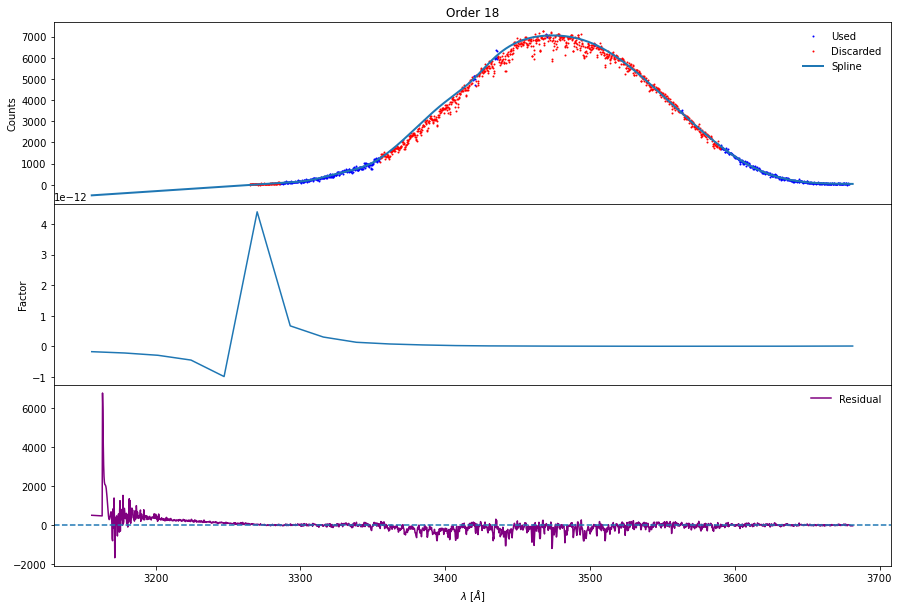

In [131]:
%matplotlib inline
fig, axs = plt.subplots(3, 1, figsize=(15, 10))
fig.subplots_adjust(hspace=0)

axs[0].plot(xhr18[mask18_hr], yhr18[mask18_hr], ls='', marker='.',
            markersize=2, label='Used', color='blue')
axs[0].plot(xhr18[np.logical_not(mask18_hr)], yhr18[np.logical_not(mask18_hr)],
            ls='', marker='.', markersize=2, label='Discarded', color='red')
axs[0].plot(hr4963.wavelength(18), y_est_custom18_hr, lw=2, label='Spline')
axs[0].legend(frameon=False)
axs[0].set_ylabel('Counts')
axs[0].set_title('Order 18')

axs[1].plot(simple_hr4963.lda, factor18_hr)
axs[1].set_ylabel('Factor')

axs[2].plot(hr4963.wavelength(18), hr4963.flux(18) - y_est_custom18_hr, label='Residual', color='purple')
axs[2].legend(frameon=False)
axs[2].axhline(0, ls='--')
axs[2].set_xlabel(r'$\lambda$ [$\AA$]');

## Order 19

In [134]:
c19hr = np.logical_and(hr4963.wavelength(19) > 3186, hr4963.wavelength(19) < 3452) 
yhr19 = hr4963.flux(19)[c19hr]
xhr19 = hr4963.wavelength(19)[c19hr]

mask19_hr = (xhr19 < 3193) + (xhr19 > 3208) * (xhr19 < 3212) \
           + (xhr19 > 3236) * (xhr19 < 3239) + (xhr19 > 3268) * (xhr19 < 3270) \
           + (xhr19 > 3293.3) * (xhr19 < 3295) + (xhr19 > 3324.6) * (xhr19 < 3325.8) \
           + (xhr19 > 3351) * (xhr19 < 3355) + (xhr19 > 3378) * (xhr19 < 3476)

knots19_hr = np.array([3189, 3210, 3237.5, 3269,
                       3294, 3325, 3353, 3380, 3418, 3446, 3468])

In [136]:
model_custom19_hr = get_natural_cubic_spline_model(x=xhr19[mask19_hr],
                                                y=yhr19[mask19_hr],
                                                minval=np.min(xhr19),
                                                maxval=np.max(xhr19),
                                                knots=knots19_hr)
y_est_custom19_hr = model_custom19_hr.predict(hr4963.wavelength(19))

In [137]:
obs_flux19_hr = spectres(simple_hr4963.lda, xhr19,
                         y_est_custom19_hr, verbose=False)
factor19_hr = reference_hrflux(simple_hr4963.lda)/obs_flux19_hr

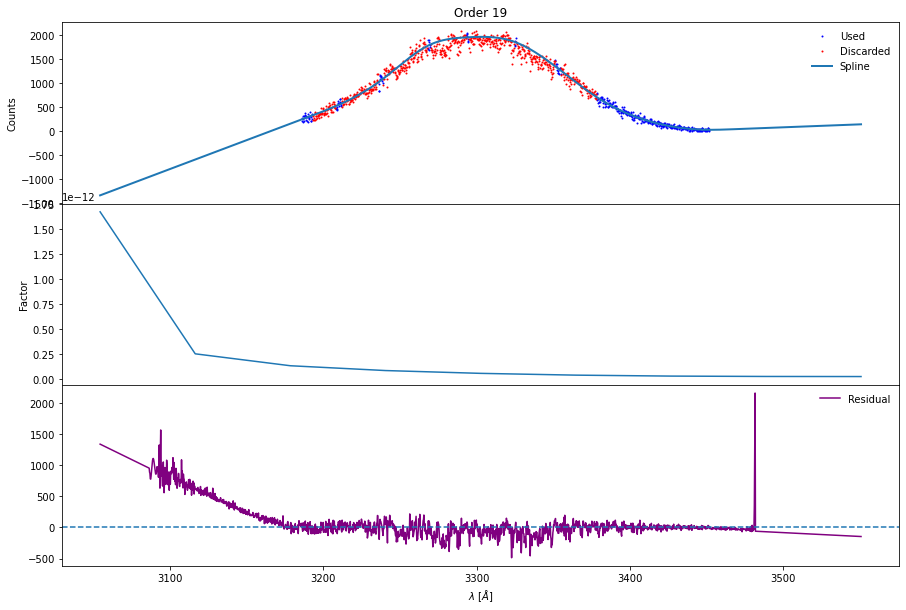

In [138]:
%matplotlib inline
fig, axs = plt.subplots(3, 1, figsize=(15, 10))
fig.subplots_adjust(hspace=0)

axs[0].plot(xhr19[mask19_hr], yhr19[mask19_hr],
            ls='', marker='.', markersize=2, label='Used', color='blue')
axs[0].plot(xhr19[np.logical_not(mask19_hr)],
            yhr19[np.logical_not(mask19_hr)],
            ls='', marker='.', markersize=2, label='Discarded', color='red')
axs[0].plot(hr4963.wavelength(19), y_est_custom19_hr, lw=2, label='Spline')
axs[0].legend(frameon=False)
axs[0].set_ylabel('Counts')
axs[0].set_title('Order 19')

axs[1].plot(simple_hr4963.lda, factor19_hr)
axs[1].set_ylabel('Factor')

axs[2].plot(hr4963.wavelength(19), hr4963.flux(19) - y_est_custom19_hr,
            label='Residual', color='purple')
axs[2].legend(frameon=False)
axs[2].axhline(0, ls='--')
axs[2].set_xlabel(r'$\lambda$ [$\AA$]');

## Order 20

In [140]:
yhr20 = hr4963.flux(20)[hr4963.wavelength(20) < 3300]
xhr20 = hr4963.wavelength(20)[hr4963.wavelength(20) < 3300]

mask20_hr = (xhr20 > 3060) * (xhr20 < 3260)

knots20_hr = np.array([3062, 3093, 3100, 3150, 3187, 3220, 3249])

In [141]:
model_custom20_hr = get_natural_cubic_spline_model(x=xhr20,
                                                 y=yhr20,
                                                 minval=np.min(xhr20),
                                                 maxval=np.max(xhr20),
                                                 knots=knots20_hr)
y_est_custom20_hr = model_custom20_hr.predict(hr4963.wavelength(20))

In [143]:
obs_flux20_hr = spectres(simple_hr4963.lda, xhr20,
                         y_est_custom20_hr, verbose=False)
factor20_hr = reference_hrflux(simple_hr4963.lda)/obs_flux20_hr

Text(0.5, 0, '$\\lambda$ [$\\AA$]')

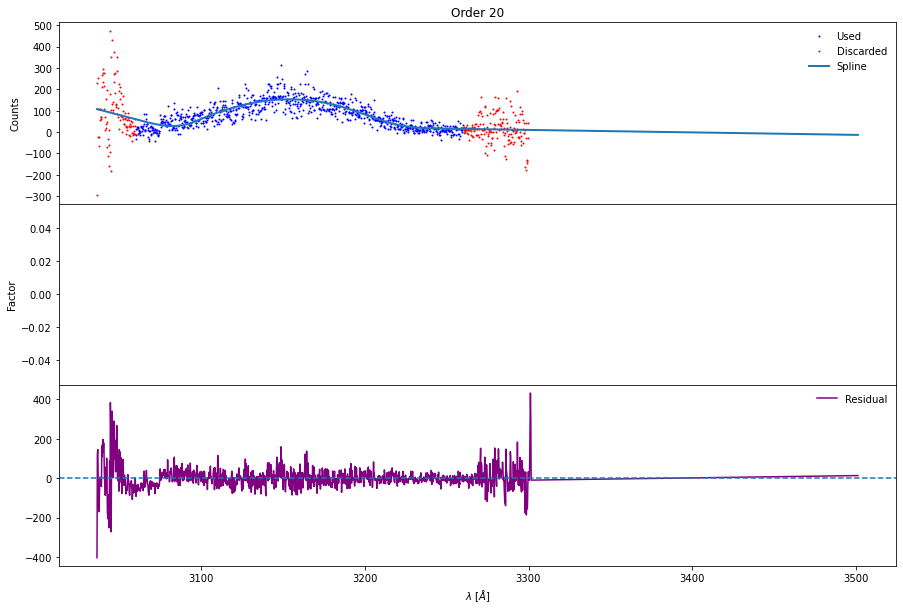

In [145]:
%matplotlib inline
fig, axs = plt.subplots(3, 1, figsize=(15, 10))
fig.subplots_adjust(hspace=0)

axs[0].plot(xhr20[mask20_hr], yhr20[mask20_hr], 
            ls='', marker='.', markersize=2, label='Used', color='blue')
axs[0].plot(xhr20[np.logical_not(mask20_hr)], yhr20[np.logical_not(mask20_hr)], 
            ls='', marker='.', markersize=2, label='Discarded', color='red')
axs[0].plot(hr4963.wavelength(20), y_est_custom20_hr, lw=2, label='Spline')
axs[0].legend(frameon=False)
axs[0].set_ylabel('Counts')
axs[0].set_title('Order 20')
#axs[0].set_xlim(3050, 3300)
#axs[0].set_ylim(-2000, 4000)

axs[1].plot(simple_hr4963.lda, factor20_hr)
axs[1].set_ylabel('Factor')
#axs[1].set_xlim(3050, 3300)

axs[2].plot(hr4963.wavelength(20), hr4963.flux(20) - y_est_custom20_hr,
            label='Residual', color='purple')
axs[2].legend(frameon=False)
axs[2].axhline(0, ls='--')
axs[2].set_xlabel(r'$\lambda$ [$\AA$]')
#axs[2].set_ylim(-2000, 2000)
#axs[2].set_xlim(3050, 3300)

In [146]:
simple_hr4963.flux[:] = y_est_custom_model_hr

In [147]:
spline_flux_hr = [
    y_est_custom6_hr,
    y_est_custom7_hr,
    y_est_custom8_hr,
    y_est_custom9_hr,
    y_est_custom10_hr,
    y_est_custom11_hr,
    y_est_custom12_hr,
    y_est_custom13_hr,
    y_est_custom14_hr,
    y_est_custom15_hr,
    y_est_custom16_hr,
    y_est_custom17_hr,
    y_est_custom18_hr,
    y_est_custom19_hr,
    y_est_custom20_hr
]

In [149]:
for i in range(6, 21):
    hr4963.flux(i)[:] =  spline_flux_hr[i - 6]
    print('Order {:} succesful for HR'.format(i))

Order 6 succesful for HR
Order 7 succesful for HR
Order 8 succesful for HR
Order 9 succesful for HR
Order 10 succesful for HR
Order 11 succesful for HR
Order 12 succesful for HR
Order 13 succesful for HR
Order 14 succesful for HR
Order 15 succesful for HR
Order 16 succesful for HR
Order 17 succesful for HR
Order 18 succesful for HR
Order 19 succesful for HR
Order 20 succesful for HR


In [150]:
flux_calibrate_multispec(J1448, hr4963, simple_hr4963)
flux_calibrate_multispec(J2101, hr4963, simple_hr4963)
flux_calibrate_multispec(J2119, hr4963, simple_hr4963)

Flux calibrating order : 6

Spectres: new_wavs contains values outside the range in spec_wavs, new_fluxes and new_errs will be filled with the value set in the 'fill' keyword argument. 

Flux calibrating order : 7

Spectres: new_wavs contains values outside the range in spec_wavs, new_fluxes and new_errs will be filled with the value set in the 'fill' keyword argument. 

Flux calibrating order : 8
Flux calibrating order : 9
Flux calibrating order : 10
Flux calibrating order : 11

Spectres: new_wavs contains values outside the range in spec_wavs, new_fluxes and new_errs will be filled with the value set in the 'fill' keyword argument. 

Flux calibrating order : 12

Spectres: new_wavs contains values outside the range in spec_wavs, new_fluxes and new_errs will be filled with the value set in the 'fill' keyword argument. 

Flux calibrating order : 13

Spectres: new_wavs contains values outside the range in spec_wavs, new_fluxes and new_errs will be filled with the value set in the 'fill' 

In [74]:
#flux_calibrate_multispec(J0950, ltt7379, simple_ltt7379)
#flux_calibrate_multispec(J1146, ltt7379, simple_ltt7379)

Flux calibrating order : 6

Spectres: new_wavs contains values outside the range in spec_wavs, new_fluxes and new_errs will be filled with the value set in the 'fill' keyword argument. 

Flux calibrating order : 7

Spectres: new_wavs contains values outside the range in spec_wavs, new_fluxes and new_errs will be filled with the value set in the 'fill' keyword argument. 

Flux calibrating order : 8

Spectres: new_wavs contains values outside the range in spec_wavs, new_fluxes and new_errs will be filled with the value set in the 'fill' keyword argument. 

Flux calibrating order : 9

Spectres: new_wavs contains values outside the range in spec_wavs, new_fluxes and new_errs will be filled with the value set in the 'fill' keyword argument. 

Flux calibrating order : 10

Spectres: new_wavs contains values outside the range in spec_wavs, new_fluxes and new_errs will be filled with the value set in the 'fill' keyword argument. 

Flux calibrating order : 11

Spectres: new_wavs contains values 

/home/benjamin/Documents/analogs/magE/spec/spec_classes.py:182: RuntimeWarning: divide by zero encountered in true_divide
  calibration_factor = reference_flux(ref_lda) / obs_flux
/home/benjamin/Documents/analogs/magE/spec/spec_classes.py:184: RuntimeWarning: invalid value encountered in multiply
  calibrated_flux = multispec_target.flux(order) * calibration_factor
/home/benjamin/Documents/analogs/magE/spec/spec_classes.py:185: RuntimeWarning: invalid value encountered in multiply
  calibrated_error = multispec_target.noise(order) * calibration_factor



Spectres: new_wavs contains values outside the range in spec_wavs, new_fluxes and new_errs will be filled with the value set in the 'fill' keyword argument. 

Flux calibrating order : 13

Spectres: new_wavs contains values outside the range in spec_wavs, new_fluxes and new_errs will be filled with the value set in the 'fill' keyword argument. 

Flux calibrating order : 14

Spectres: new_wavs contains values outside the range in spec_wavs, new_fluxes and new_errs will be filled with the value set in the 'fill' keyword argument. 

Flux calibrating order : 15

Spectres: new_wavs contains values outside the range in spec_wavs, new_fluxes and new_errs will be filled with the value set in the 'fill' keyword argument. 

Flux calibrating order : 16

Spectres: new_wavs contains values outside the range in spec_wavs, new_fluxes and new_errs will be filled with the value set in the 'fill' keyword argument. 

Flux calibrating order : 17

Spectres: new_wavs contains values outside the range in spe

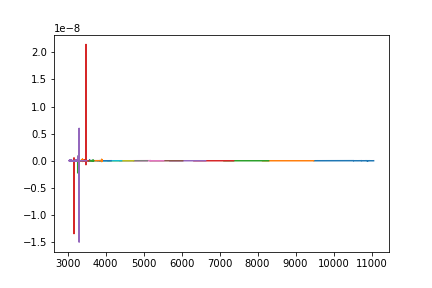

In [153]:
%matplotlib widget
for i in range(6, 21):
    J2119.plot(i)

In [155]:
#J0950.to_fits("/home/benjamin/Documents/analogs/specs/fits/j0950+0042_1.fits")
#J1448.to_fits("/home/benjamin/Documents/analogs/specs/fits/j1448-0110_1.fits")
#J2101.to_fits("/home/benjamin/Documents/analogs/specs/fits/j2101-0555_1.fits")
#J2119.to_fits("/home/benjamin/Documents/analogs/specs/fits/j2119+0052_1.fits")